# ANN-Based Ground Motion Prediction Equation (GMPE)
### NGA-Sub Subduction Zone — Vemula et al. (2023)

**Architecture:** 6 inputs → 10 neurons (HL1, ELU) → 12 neurons (HL2, ELU) → 108 outputs (linear)  
**Inputs:** Mw, RJB, ln(RJB), ZTOR, ln(Vs30), Region Flag  
**Outputs:** 105 PSA (0.01–10 s) + PGA + PGV + PGD  
**Optimizer:** Adam with exponential LR decay | **Regularization:** L2 | **Tuning:** Bayesian (Optuna)

---

## Cell 1 — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings, pickle, json, os
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks, Input
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

print(f"TF version  : {tf.__version__}")
print(f"Optuna ver  : {optuna.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")

TF version  : 2.19.0
Optuna ver  : 4.5.0
GPU devices : []


## Cell 2 — Load & Inspect Filtered Dataset

In [2]:
CSV_PATH = 'NGAsub_flatfile_filtered.csv'   # <-- update path if needed
df = pd.read_csv(CSV_PATH)

print(f"Shape              : {df.shape}")
print(f"Unique events      : {df['NGAsubEQID'].nunique()}")
print(f"Unique stations    : {df['NGAsubSSN'].nunique()}")
print()
print("Magnitude range    :", df['Earthquake_Magnitude'].min(), "–", df['Earthquake_Magnitude'].max())
print("RJB range (km)     :", df['Rjb_km'].min(), "–", df['Rjb_km'].max())
print("Vs30 range (m/s)   :", df['Vs30_Selected_for_Analysis_m_s'].min(), "–",
      df['Vs30_Selected_for_Analysis_m_s'].max())
print()
print("Region distribution:")
print(df['DatabaseRegion'].value_counts().to_string())

Shape              : (8907, 227)
Unique events      : 188
Unique stations    : 2894

Magnitude range    : 4.1 – 9.12
RJB range (km)     : 0.0 – 999.0898298
Vs30 range (m/s)   : 94.7 – 2229.8

Region distribution:
DatabaseRegion
Japan                    5493
Taiwan                   1247
SouthAmerica              910
Alaska                    770
Cascadia                  381
CentralAmerica&Mexico     106


## Cell 3 — Region Flag Mapping & Derived Input Features

In [3]:
# Paper: AK=1, CAS=2, CAM=3, JP=4, SA=5, TW=6
REGION_MAP = {
    'Alaska'                : 1,
    'Cascadia'              : 2,
    'CentralAmerica&Mexico' : 3,
    'Japan'                 : 4,
    'SouthAmerica'          : 5,
    'Taiwan'                : 6,
}
REGION_NAMES  = {v: k[:2].upper() if k != 'CentralAmerica&Mexico' else 'CAM'
                 for k, v in REGION_MAP.items()}
REGION_NAMES  = {1:'AK', 2:'CAS', 3:'CAM', 4:'JP', 5:'SA', 6:'TW'}
REGION_COLORS = {1:'#1f77b4', 2:'#ff7f0e', 3:'#d62728',
                 4:'#9467bd', 5:'#17becf', 6:'#2ca02c'}

df['Region_Flag'] = df['DatabaseRegion'].map(REGION_MAP)
n_unmapped = df['Region_Flag'].isna().sum()
if n_unmapped:
    print(f"WARNING: {n_unmapped} unmapped records — dropping.")
    df = df.dropna(subset=['Region_Flag'])

# Derived features  — clip RJB at 0.01 km to avoid log(0)
df['log_Rjb']  = np.log(df['Rjb_km'].clip(lower=0.01))
df['log_Vs30'] = np.log(df['Vs30_Selected_for_Analysis_m_s'])

INPUT_COLS = ['Earthquake_Magnitude', 'Rjb_km', 'log_Rjb',
              'Ztor_km', 'log_Vs30', 'Region_Flag']
INPUT_LABELS = ['Mw', 'RJB (km)', 'ln(RJB)', 'ZTOR (km)', 'ln(Vs30)', 'Region Flag']

print("Input feature statistics:")
print(df[INPUT_COLS].describe().round(3))

Input feature statistics:
       Earthquake_Magnitude    Rjb_km   log_Rjb   Ztor_km  log_Vs30  \
count              8907.000  8907.000  8907.000  8907.000  8907.000   
mean                  6.906   246.738     5.185    42.104     6.045   
std                   1.083   200.313     0.968    34.430     0.460   
min                   4.100     0.000    -4.605     0.000     4.551   
25%                   6.250   114.841     4.744    17.908     5.753   
50%                   6.760   184.457     5.217    31.881     6.082   
75%                   7.150   306.819     5.726    50.000     6.374   
max                   9.120   999.090     6.907   186.004     7.710   

       Region_Flag  
count     8907.000  
mean         4.025  
std          1.274  
min          1.000  
25%          4.000  
50%          4.000  
75%          4.000  
max          6.000  


## Cell 4 — Define Output Columns (108 total)

In [4]:
# 105 PSA periods from 0.01 s to 10 s
PSA_COLS = [
    'T0pt010S','T0pt020S','T0pt022S','T0pt025S','T0pt029S',
    'T0pt030S','T0pt032S','T0pt035S','T0pt036S','T0pt040S',
    'T0pt042S','T0pt044S','T0pt045S','T0pt046S','T0pt048S',
    'T0pt050S','T0pt055S','T0pt060S','T0pt065S','T0pt067S',
    'T0pt070S','T0pt075S','T0pt080S','T0pt085S','T0pt090S',
    'T0pt095S','T0pt100S','T0pt110S','T0pt120S','T0pt130S',
    'T0pt133S','T0pt140S','T0pt150S','T0pt160S','T0pt170S',
    'T0pt180S','T0pt190S','T0pt200S','T0pt220S','T0pt240S',
    'T0pt250S','T0pt260S','T0pt280S','T0pt290S','T0pt300S',
    'T0pt320S','T0pt340S','T0pt350S','T0pt360S','T0pt380S',
    'T0pt400S','T0pt420S','T0pt440S','T0pt450S','T0pt460S',
    'T0pt480S','T0pt500S','T0pt550S','T0pt600S','T0pt650S',
    'T0pt667S','T0pt700S','T0pt750S','T0pt800S','T0pt850S',
    'T0pt900S','T0pt950S','T1pt000S','T1pt100S','T1pt200S',
    'T1pt300S','T1pt400S','T1pt500S','T1pt600S','T1pt700S',
    'T1pt800S','T1pt900S','T2pt000S','T2pt200S','T2pt400S',
    'T2pt500S','T2pt600S','T2pt800S','T3pt000S','T3pt200S',
    'T3pt400S','T3pt500S','T3pt600S','T3pt800S','T4pt000S',
    'T4pt200S','T4pt400S','T4pt600S','T4pt800S','T5pt000S',
    'T5pt500S','T6pt000S','T6pt500S','T7pt000S','T7pt500S',
    'T8pt000S','T8pt500S','T9pt000S','T9pt500S','T10pt000S',
]
PERIOD_VALUES = [
    0.01,0.02,0.022,0.025,0.029,0.03,0.032,0.035,0.036,0.04,
    0.042,0.044,0.045,0.046,0.048,0.05,0.055,0.06,0.065,0.067,
    0.07,0.075,0.08,0.085,0.09,0.095,0.1,0.11,0.12,0.13,
    0.133,0.14,0.15,0.16,0.17,0.18,0.19,0.2,0.22,0.24,
    0.25,0.26,0.28,0.29,0.3,0.32,0.34,0.35,0.36,0.38,
    0.4,0.42,0.44,0.45,0.46,0.48,0.5,0.55,0.6,0.65,
    0.667,0.7,0.75,0.8,0.85,0.9,0.95,1.0,1.1,1.2,
    1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.2,2.4,
    2.5,2.6,2.8,3.0,3.2,3.4,3.5,3.6,3.8,4.0,
    4.2,4.4,4.6,4.8,5.0,5.5,6.0,6.5,7.0,7.5,
    8.0,8.5,9.0,9.5,10.0,
]
OUTPUT_COLS   = PSA_COLS + ['PGA_g', 'PGV_cm_sec', 'PGD_cm']
OUTPUT_LABELS = [f'{p}s' for p in PERIOD_VALUES] + ['PGA','PGV','PGD']
# Period labels for paper convention: 0=PGA, -1=PGV, -2=PGD
OUTPUT_PERIOD_LABELS = PERIOD_VALUES + [0, -1, -2]

assert len(PSA_COLS) == 105, f"Expected 105 PSA cols, got {len(PSA_COLS)}"
print(f"PSA columns  : {len(PSA_COLS)}")
print(f"Total outputs: {len(OUTPUT_COLS)}")   # 108

PSA columns  : 105
Total outputs: 108


## Cell 5 — Prepare Feature Matrix X and Log-Target Matrix Y

In [5]:
# Remove any record with non-positive output value
pos_mask = (df[OUTPUT_COLS] > 0).all(axis=1)
df_model = df[pos_mask].copy().reset_index(drop=True)
print(f"Records after positive-output filter: {len(df_model)}  "
      f"(dropped {(~pos_mask).sum()})")

# Store metadata for mixed-effects analysis
EVENT_IDS   = df_model['NGAsubEQID'].values.astype(int)
STATION_IDS = df_model['NGAsubSSN'].values.astype(int)
REGION_IDS  = df_model['Region_Flag'].values.astype(int)
MW_ALL      = df_model['Earthquake_Magnitude'].values
RJB_ALL     = df_model['Rjb_km'].values
VS30_ALL    = df_model['Vs30_Selected_for_Analysis_m_s'].values

X_raw = df_model[INPUT_COLS].values                  # shape (n, 6)
Y_log = np.log(df_model[OUTPUT_COLS].values)         # shape (n, 108), natural log

print(f"X_raw shape  : {X_raw.shape}")
print(f"Y_log shape  : {Y_log.shape}")
print(f"Y_log range  : {Y_log.min():.3f} to {Y_log.max():.3f}")

Records after positive-output filter: 8907  (dropped 0)
X_raw shape  : (8907, 6)
Y_log shape  : (8907, 108)
Y_log range  : -18.678 to 6.113


## Cell 6 — Z-Score Normalization (Equation 2) → Tables S1 & S2

In [6]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_raw)   # (n, 6)
Y_scaled = scaler_Y.fit_transform(Y_log)   # (n, 108)

# ── Table S1: Input scaling parameters
table_S1 = pd.DataFrame({
    'Parameter' : INPUT_LABELS,
    'Mean (μ)'  : scaler_X.mean_.round(6),
    'Std (σ)'   : scaler_X.scale_.round(6),
})
print("═" * 55)
print("  TABLE S1 — Input Scaling Parameters")
print("═" * 55)
print(table_S1.to_string(index=False))
table_S1.to_csv('table_S1_input_scaling.csv', index=False)

# ── Table S2: Output scaling parameters
table_S2 = pd.DataFrame({
    'Output'   : OUTPUT_LABELS,
    'Period'   : OUTPUT_PERIOD_LABELS,
    'Mean (μ)' : scaler_Y.mean_.round(6),
    'Std (σ)'  : scaler_Y.scale_.round(6),
})
print()
print("  TABLE S2 — Output Scaling Parameters (first 15 shown)")
print("═" * 55)
print(table_S2.head(15).to_string(index=False))
print(f"  ... {len(table_S2)-15} more rows")
table_S2.to_csv('table_S2_output_scaling.csv', index=False)
print("\nSaved: table_S1_input_scaling.csv, table_S2_output_scaling.csv")

═══════════════════════════════════════════════════════
  TABLE S1 — Input Scaling Parameters
═══════════════════════════════════════════════════════
  Parameter   Mean (μ)    Std (σ)
         Mw   6.905616   1.083368
   RJB (km) 246.738344 200.301782
    ln(RJB)   5.184916   0.967694
  ZTOR (km)  42.104458  34.427912
   ln(Vs30)   6.045441   0.459721
Region Flag   4.025373   1.273803

  TABLE S2 — Output Scaling Parameters (first 15 shown)
═══════════════════════════════════════════════════════
Output  Period  Mean (μ)  Std (σ)
 0.01s   0.010 -4.807396 2.410723
 0.02s   0.020 -4.794537 2.414745
0.022s   0.022 -4.790151 2.415946
0.025s   0.025 -4.781492 2.418252
0.029s   0.029 -4.765980 2.423374
 0.03s   0.030 -4.761302 2.425013
0.032s   0.032 -4.751766 2.428532
0.035s   0.035 -4.736037 2.434026
0.036s   0.036 -4.730760 2.435660
 0.04s   0.040 -4.707457 2.442631
0.042s   0.042 -4.693898 2.446561
0.044s   0.044 -4.680035 2.450110
0.045s   0.045 -4.672788 2.451670
0.046s   0.046 -4.66550

## Cell 7 — Train / Validation / Test Split (70 / 15 / 15%)

In [7]:
idx_all = np.arange(len(X_scaled))

idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=42)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

X_train, Y_train = X_scaled[idx_train], Y_scaled[idx_train]
X_val,   Y_val   = X_scaled[idx_val],   Y_scaled[idx_val]
X_test,  Y_test  = X_scaled[idx_test],  Y_scaled[idx_test]

n = len(X_scaled)
print(f"Total    : {n:6d}  (100.0%)")
print(f"Training : {len(X_train):6d}  ({len(X_train)/n*100:.1f}%)")
print(f"Validation: {len(X_val):5d}  ({len(X_val)/n*100:.1f}%)")
print(f"Testing  : {len(X_test):6d}  ({len(X_test)/n*100:.1f}%)")

Total    :   8907  (100.0%)
Training :   6234  (70.0%)
Validation:  1336  (15.0%)
Testing  :   1337  (15.0%)


## Cell 8 — ANN Model Builder (Figure 5 Architecture)

In [8]:
def build_model(hidden1=10, hidden2=12, l2_reg=3.28e-4,
                lr=0.0064, lr_drop=0.8677, lr_drop_period=200):
    """
    Architecture: 6 → hidden1 [ELU] → hidden2 [ELU] → 108 [linear]
    Optimizer   : Adam with exponential LR decay (Equation 3 / Section 3)
    """
    inp = Input(shape=(6,), name='inputs')
    x   = layers.Dense(hidden1, activation='elu', name='HL1',
                        kernel_regularizer=regularizers.l2(l2_reg))(inp)
    x   = layers.Dense(hidden2, activation='elu', name='HL2',
                        kernel_regularizer=regularizers.l2(l2_reg))(x)
    out = layers.Dense(108, activation='linear', name='outputs')(x)
    model = Model(inputs=inp, outputs=out)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=lr,
        decay_steps=lr_drop_period,
        decay_rate=lr_drop,
        staircase=False,
    )
    model.compile(optimizer=tf.keras.optimizers.Adam(lr_schedule),
                  loss='mse', metrics=['mse'])
    return model

# Show architecture for N2 (paper's final model)
model_demo = build_model()
model_demo.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HL1 (Dense)                     │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HL2 (Dense)                     │ (None, 12)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 108)            │         1,404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,606 (6.27 KB)

 Trainable params: 1,606 (6.27 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 9 — Bayesian Hyperparameter Optimization (Optuna / TPE)

Best trial: 45. Best value: 0.0995361: 100%|██████████| 50/50 [07:30<00:00,  9.02s/it]



══════════════════════════════════════════════════
  Bayesian Optimization Results
══════════════════════════════════════════════════
  Best validation MSE : 0.09954
  Best hyperparameters:
    hidden1        : 11
    hidden2        : 15
    l2_reg         : 1.7371889787251766e-05
    lr             : 0.09596583159228286
    lr_drop        : 0.8598803955494323
    lr_period      : 188


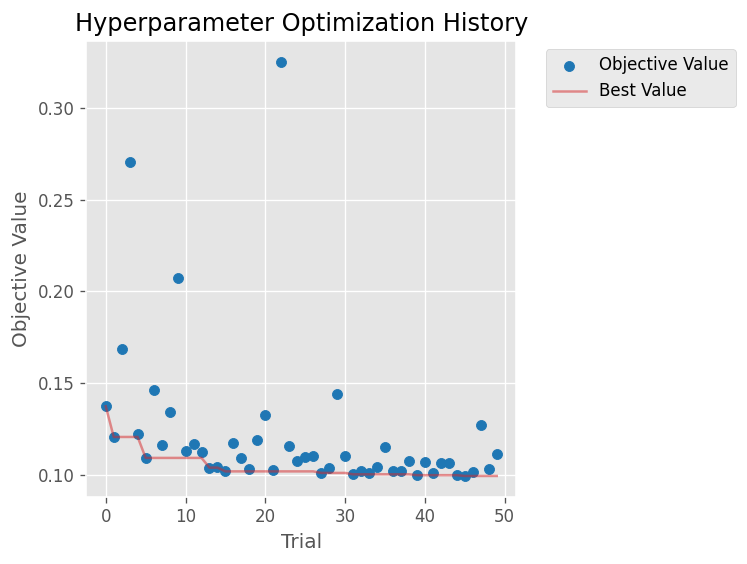

In [9]:
# NOTE: Set N_TRIALS=50 for production quality; reduce for quick testing
N_TRIALS = 50

def objective(trial):
    h1  = trial.suggest_int  ('hidden1',    6,  20)
    h2  = trial.suggest_int  ('hidden2',    6,  24)
    l2  = trial.suggest_float('l2_reg',  1e-5, 1e-2, log=True)
    lr  = trial.suggest_float('lr',      1e-4, 1e-1, log=True)
    dr  = trial.suggest_float('lr_drop', 0.50, 0.99)
    dp  = trial.suggest_int  ('lr_period', 50,  500)

    m  = build_model(h1, h2, l2, lr, dr, dp)
    es = callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                 restore_best_weights=True)
    hist = m.fit(X_train, Y_train,
                 validation_data=(X_val, Y_val),
                 epochs=500, batch_size=256,
                 callbacks=[es], verbose=0)
    return min(hist.history['val_loss'])

study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n" + "═"*50)
print("  Bayesian Optimization Results")
print("═"*50)
print(f"  Best validation MSE : {study.best_value:.5f}")
print("  Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"    {k:15s}: {v}")

# Optuna optimization history plot
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Hyperparameter Optimization History')
plt.tight_layout()
plt.savefig('fig_optuna_history.png')
plt.show()

## Cell 10 — Train N1 (Optuna Best) and N2 (Paper's Network)

In [10]:
def train_model(params, name, epochs=3000, patience=100, batch_size=256):
    m  = build_model(**params)
    es = callbacks.EarlyStopping(monitor='val_loss', patience=patience,
                                 restore_best_weights=True, verbose=0)
    hist = m.fit(X_train, Y_train,
                 validation_data=(X_val, Y_val),
                 epochs=epochs, batch_size=batch_size,
                 callbacks=[es], verbose=0)
    tr_mse  = hist.history['loss'][-1]
    val_mse = min(hist.history['val_loss'])
    tst_mse = m.evaluate(X_test, Y_test, verbose=0)[0]
    k_params = m.count_params()
    print(f"  {name:<30s}  Train:{tr_mse:.5f}  Val:{val_mse:.5f}  "
          f"Test:{tst_mse:.5f}  k={k_params}")
    return m, hist, tr_mse, val_mse, tst_mse, k_params

print("Training models…")
print(f"{'Model':<30s}  {'Train MSE':>10}  {'Val MSE':>9}  {'Test MSE':>9}  {'k':>6}")
print("─"*70)

# N1 — best Optuna result
p_N1 = {
    'hidden1'       : study.best_params['hidden1'],
    'hidden2'       : study.best_params['hidden2'],
    'l2_reg'        : study.best_params['l2_reg'],
    'lr'            : study.best_params['lr'],
    'lr_drop'       : study.best_params['lr_drop'],
    'lr_drop_period': study.best_params['lr_period'],
}
model_N1, hist_N1, tr1, val1, tst1, k1 = train_model(p_N1, 'N1 (Optuna best)')

# N2 — paper's final selected network
p_N2 = {
    'hidden1'       : 10,
    'hidden2'       : 12,
    'l2_reg'        : 3.28e-4,
    'lr'            : 0.0064,
    'lr_drop'       : 0.8677,
    'lr_drop_period': 200,
}
model_N2, hist_N2, tr2, val2, tst2, k2 = train_model(p_N2, 'N2 (Paper — 10×12)')

Training models…
Model                            Train MSE    Val MSE   Test MSE       k
──────────────────────────────────────────────────────────────────────
  N1 (Optuna best)                Train:0.10016  Val:0.10121  Test:0.10179  k=1985
  N2 (Paper — 10×12)              Train:0.11879  Val:0.11593  Test:0.11826  k=1606


## Cell 11 — AIC / BIC Model Selection (Equation 4) + Training History

═══════════════════════════════════════════════════════════════════════════
  Model                     Train      Val     Test      k       AIC       BIC
───────────────────────────────────────────────────────────────────────────
  N1 (Optuna best)        0.10016  0.10121  0.10179   1985    3.3847    5.5301
  N2 (Paper 10×12)        0.11879  0.11593  0.11826   1606    3.3166    5.0524
═══════════════════════════════════════════════════════════════════════════
  → Lower AIC/BIC = preferred model (N2 per paper)


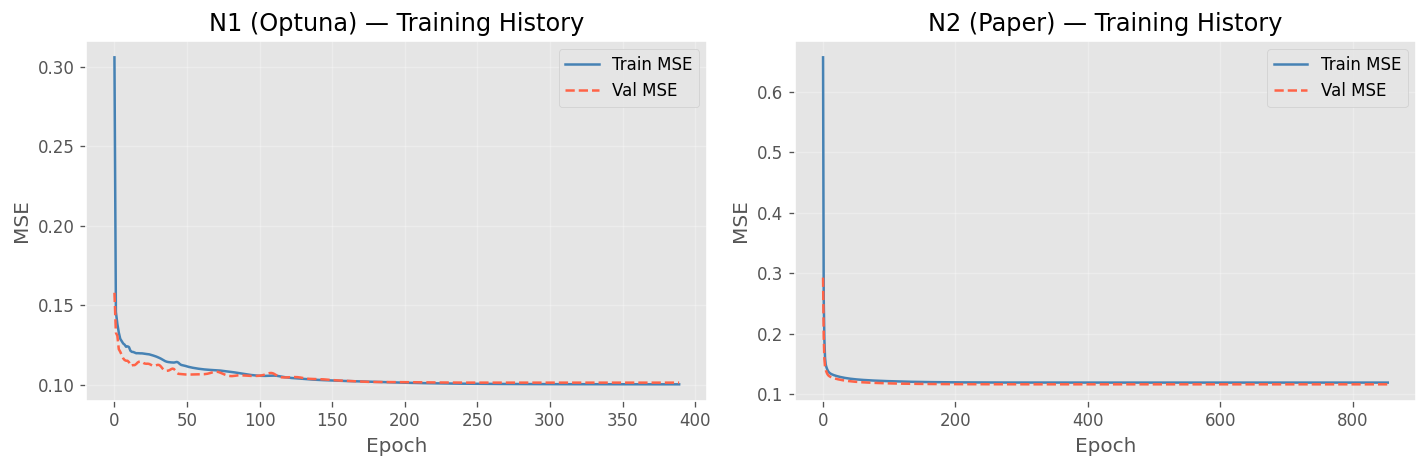

Saved: fig_training_history.png


In [11]:
def compute_aic_bic(model, X, Y, label=''):
    Yp  = model.predict(X, verbose=0)
    SSE = float(np.sum((Y - Yp)**2))
    n   = len(X)
    k   = model.count_params()
    AIC = np.log(SSE / (n - k)) + 2 * (k / n)
    BIC = np.log(SSE / (n - k)) + (k / n) * np.log(n)
    return AIC, BIC

aic1, bic1 = compute_aic_bic(model_N1, X_train, Y_train)
aic2, bic2 = compute_aic_bic(model_N2, X_train, Y_train)

print("═"*75)
print(f"  {'Model':<22}  {'Train':>7}  {'Val':>7}  {'Test':>7}  "
      f"{'k':>5}  {'AIC':>8}  {'BIC':>8}")
print("─"*75)
print(f"  {'N1 (Optuna best)':<22}  {tr1:>7.5f}  {val1:>7.5f}  {tst1:>7.5f}  "
      f"{k1:>5}  {aic1:>8.4f}  {bic1:>8.4f}")
print(f"  {'N2 (Paper 10×12)':<22}  {tr2:>7.5f}  {val2:>7.5f}  {tst2:>7.5f}  "
      f"{k2:>5}  {aic2:>8.4f}  {bic2:>8.4f}")
print("═"*75)
print("  → Lower AIC/BIC = preferred model (N2 per paper)")

model_final = model_N2  # Use N2 as final model

# Training history plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name in zip(axes, [hist_N1, hist_N2], ['N1 (Optuna)', 'N2 (Paper)']):
    ax.plot(hist.history['loss'],     color='steelblue', lw=1.5, label='Train MSE')
    ax.plot(hist.history['val_loss'], color='tomato',    lw=1.5, linestyle='--', label='Val MSE')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.set_title(f'{name} — Training History')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_training_history.png')
plt.show()
print("Saved: fig_training_history.png")

## Cell 12 — Predict on Full Dataset & Compute Residuals

In [12]:
# Predict on entire dataset (scaled → inverse → log space)
Y_pred_sc  = model_final.predict(X_scaled, verbose=0)       # scaled
Y_pred_log = scaler_Y.inverse_transform(Y_pred_sc)          # ln space, (n, 108)
Y_true_log = Y_log                                           # ln space, (n, 108)

# Total residuals Δ = Y_target – Y_predicted  (natural log)
DELTA = Y_true_log - Y_pred_log                             # (n, 108)

print(f"Y_pred_log shape  : {Y_pred_log.shape}")
print(f"DELTA shape       : {DELTA.shape}")
print(f"Global mean Δ     : {DELTA.mean():.5f}")
print(f"Global std  Δ     : {DELTA.std():.5f}")

Y_pred_log shape  : (8907, 108)
DELTA shape       : (8907, 108)
Global mean Δ     : -0.00022
Global std  Δ     : 0.80717


## Cell 13 — Mixed Effects Decomposition (Equations 5–7) → Table 2 / Table S3

In [13]:
def compute_mixed_effects(residuals, event_ids, region_ids):
    """
    Two-stage decomposition (Al Atik et al. 2010).
    Stage 1: Inter-event  δBe  = mean residual per event
    Stage 2: Inter-region δRr  = mean of (resid - δBe) per region
             Intra-event  δWes = residuals - δBe - δRr
    Returns dict with component arrays and scalar standard deviations.
    """
    n       = len(residuals)
    events  = np.unique(event_ids)
    regions = np.unique(region_ids)

    delta_Be = np.zeros(n)
    for ev in events:
        m = event_ids == ev
        delta_Be[m] = residuals[m].mean()

    r2 = residuals - delta_Be
    delta_Rr = np.zeros(n)
    for rg in regions:
        m = region_ids == rg
        delta_Rr[m] = r2[m].mean()

    delta_Wes = residuals - delta_Be - delta_Rr

    tau   = delta_Be.std()
    phi_r = delta_Rr.std()
    phi   = delta_Wes.std()
    sigma = np.sqrt(tau**2 + phi**2)   # Equation 7: no inter-region in σ

    return dict(Be=delta_Be, Rr=delta_Rr, Wes=delta_Wes,
                mean_Be=delta_Be.mean(), mean_Rr=delta_Rr.mean(),
                mean_Wes=delta_Wes.mean(),
                tau=tau, phi_r=phi_r, phi=phi, sigma=sigma)

print("Computing mixed effects for all 108 outputs…")
me_results = [compute_mixed_effects(DELTA[:, i], EVENT_IDS, REGION_IDS)
              for i in range(108)]
print("Done.")

# ── Table 2: selected periods
SEL_PERIODS = [0.01,0.02,0.03,0.04,0.05,0.1,0.2,0.3,0.5,0.75,1,2,5,10,0,-1,-2]
def get_output_idx(p):
    if p in PERIOD_VALUES: return PERIOD_VALUES.index(p)
    return {0:105, -1:106, -2:107}[p]

rows_t2 = []
for sp in SEL_PERIODS:
    i  = get_output_idx(sp)
    r  = me_results[i]
    rows_t2.append({
        'Period'           : sp,
        'Inter-event mean' : round(r['mean_Be'],  4),
        'Inter-region mean': round(r['mean_Rr'],  4),
        'Intra-event mean' : round(r['mean_Wes'], 4),
        'Inter-event std τ': round(r['tau'],       4),
        'Inter-region std' : round(r['phi_r'],     4),
        'Intra-event std ϕ': round(r['phi'],       4),
        'Sigma σ'          : round(r['sigma'],     4),
    })
table2 = pd.DataFrame(rows_t2)
print("\n" + "═"*95)
print("  TABLE 2 — Standard Deviations of the Developed Model")
print("═"*95)
print(table2.to_string(index=False))
table2.to_csv('table_2_std_deviations.csv', index=False)

# ── Table S3: all 108 outputs
me_full = pd.DataFrame([{
    'Output'           : OUTPUT_LABELS[i],
    'Period'           : OUTPUT_PERIOD_LABELS[i],
    'Inter-event mean' : me_results[i]['mean_Be'],
    'Inter-region mean': me_results[i]['mean_Rr'],
    'Intra-event mean' : me_results[i]['mean_Wes'],
    'tau'              : me_results[i]['tau'],
    'phi_r'            : me_results[i]['phi_r'],
    'phi'              : me_results[i]['phi'],
    'sigma'            : me_results[i]['sigma'],
} for i in range(108)])
me_full.to_csv('table_S3_mixed_effects_all.csv', index=False)
print("\nSaved: table_2_std_deviations.csv, table_S3_mixed_effects_all.csv")

Computing mixed effects for all 108 outputs…
Done.

═══════════════════════════════════════════════════════════════════════════════════════════════
  TABLE 2 — Standard Deviations of the Developed Model
═══════════════════════════════════════════════════════════════════════════════════════════════
 Period  Inter-event mean  Inter-region mean  Intra-event mean  Inter-event std τ  Inter-region std  Intra-event std ϕ  Sigma σ
   0.01           -0.0002                0.0               0.0             0.3767               0.0             0.7146   0.8078
   0.02           -0.0003               -0.0              -0.0             0.3798               0.0             0.7169   0.8113
   0.03           -0.0013               -0.0              -0.0             0.3878               0.0             0.7260   0.8230
   0.04           -0.0012                0.0               0.0             0.3977               0.0             0.7412   0.8412
   0.05           -0.0023               -0.0              -0.

## Cell 14 — Figure 6: Standard Deviation vs Period

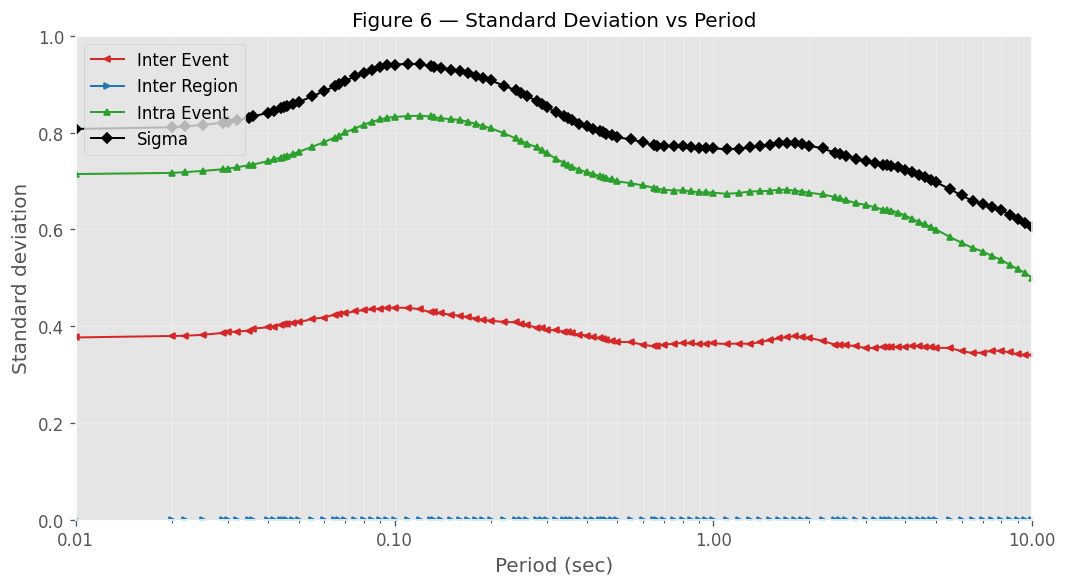

Saved: fig6_std_deviation.png


In [14]:
T_arr    = np.array(PERIOD_VALUES)
tau_arr  = np.array([me_results[i]['tau']   for i in range(105)])
phir_arr = np.array([me_results[i]['phi_r'] for i in range(105)])
phi_arr  = np.array([me_results[i]['phi']   for i in range(105)])
sig_arr  = np.array([me_results[i]['sigma'] for i in range(105)])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T_arr, tau_arr,  marker='<', ms=4, lw=1.2, color='#d62728', label='Inter Event')
ax.plot(T_arr, phir_arr, marker='>', ms=4, lw=1.2, color='#1f77b4', label='Inter Region')
ax.plot(T_arr, phi_arr,  marker='^', ms=4, lw=1.2, color='#2ca02c', label='Intra Event')
ax.plot(T_arr, sig_arr,  marker='D', ms=4, lw=1.2, color='k',       label='Sigma')
ax.set_xscale('log')
ax.set_xlabel('Period (sec)', fontsize=12)
ax.set_ylabel('Standard deviation', fontsize=12)
ax.set_title('Figure 6 — Standard Deviation vs Period', fontsize=12)
ax.set_xlim(0.01, 10); ax.set_ylim(0, 1.0)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, which='both', alpha=0.25)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.tight_layout()
plt.savefig('fig6_std_deviation.png')
plt.show()
print("Saved: fig6_std_deviation.png")

## Cell 15 — Model Performance Metrics (Table 3 / Table S4)

In [15]:
def model_performance(Y_true, Y_pred):
    """
    Golbraikh & Tropsha (2002) criteria.
    Y_true, Y_pred: 1D arrays (log scale)
    """
    Y, y   = Y_true, Y_pred
    Y_bar  = Y.mean(); y_bar = y.mean()

    R      = float(np.corrcoef(Y, y)[0, 1])
    MSE    = mean_squared_error(Y, y)
    PP     = 1.0 - MSE / np.var(Y)

    k      = np.sum(Y * y) / np.sum(Y * Y)
    kp     = np.sum(Y * y) / np.sum(y * y)

    yr0    = k  * Y                                # predicted through origin using k
    Yr0    = kp * y                                # target through origin using k'

    Ro2    = 1 - np.sum((y  - yr0)**2) / np.sum((y  - y_bar)**2)
    Rop2   = 1 - np.sum((Y  - Yr0)**2) / np.sum((Y  - Y_bar)**2)

    R2     = R**2
    a      = abs(R2 - Ro2)  / R2
    ap     = abs(R2 - Rop2) / R2

    return dict(R=R, PP=PP, k=k, kp=kp, a=a, ap=ap, Ro2=Ro2, Rop2=Rop2)

print("Computing performance metrics…")
# Use full dataset (paper uses training set)
train_true = Y_true_log[idx_train]
train_pred = Y_pred_log[idx_train]

rows_t3 = []
for sp in SEL_PERIODS:
    i  = get_output_idx(sp)
    pm = model_performance(train_true[:, i], train_pred[:, i])
    rows_t3.append({'Period': sp, **{k: round(v, 4) for k, v in pm.items()}})

table3 = pd.DataFrame(rows_t3).rename(
    columns={'kp':"k'", 'ap':"a'", 'Ro2':'Ro²', 'Rop2':"Ro'²"})
print("\n" + "═"*90)
print("  TABLE 3 — Developed Model Performance")
print("═"*90)
print(table3.to_string(index=False))
table3.to_csv('table_3_model_performance.csv', index=False)

# Full Table S4 (all periods)
rows_S4 = []
for i in range(108):
    pm = model_performance(train_true[:, i], train_pred[:, i])
    rows_S4.append({'Output': OUTPUT_LABELS[i],
                    'Period': OUTPUT_PERIOD_LABELS[i],
                    **{k: round(v, 4) for k, v in pm.items()}})
pd.DataFrame(rows_S4).to_csv('table_S4_performance_all.csv', index=False)
print("\nSaved: table_3_model_performance.csv, table_S4_performance_all.csv")

Computing performance metrics…

══════════════════════════════════════════════════════════════════════════════════════════
  TABLE 3 — Developed Model Performance
══════════════════════════════════════════════════════════════════════════════════════════
 Period      R     PP      k     k'      a  a'    Ro²   Ro'²
   0.01 0.9429 0.8891 0.9775 1.0001 0.0128 0.0 0.8778 0.8891
   0.02 0.9425 0.8883 0.9772 1.0001 0.0130 0.0 0.8768 0.8883
   0.03 0.9414 0.8862 0.9763 1.0001 0.0135 0.0 0.8743 0.8862
   0.04 0.9397 0.8830 0.9749 1.0001 0.0143 0.0 0.8703 0.8830
   0.05 0.9373 0.8786 0.9729 1.0002 0.0154 0.0 0.8651 0.8786
   0.10 0.9304 0.8656 0.9640 1.0003 0.0184 0.0 0.8497 0.8656
   0.20 0.9336 0.8716 0.9638 1.0002 0.0162 0.0 0.8575 0.8716
   0.30 0.9393 0.8823 0.9683 1.0003 0.0135 0.0 0.8703 0.8823
   0.50 0.9438 0.8908 0.9742 1.0001 0.0118 0.0 0.8802 0.8908
   0.75 0.9436 0.8904 0.9772 1.0003 0.0123 0.0 0.8794 0.8904
   1.00 0.9422 0.8877 0.9790 1.0003 0.0132 0.0 0.8760 0.8877
   2.00 0.9388

## Cell 16 — Figure 7: Inter-event & Inter-region Residuals

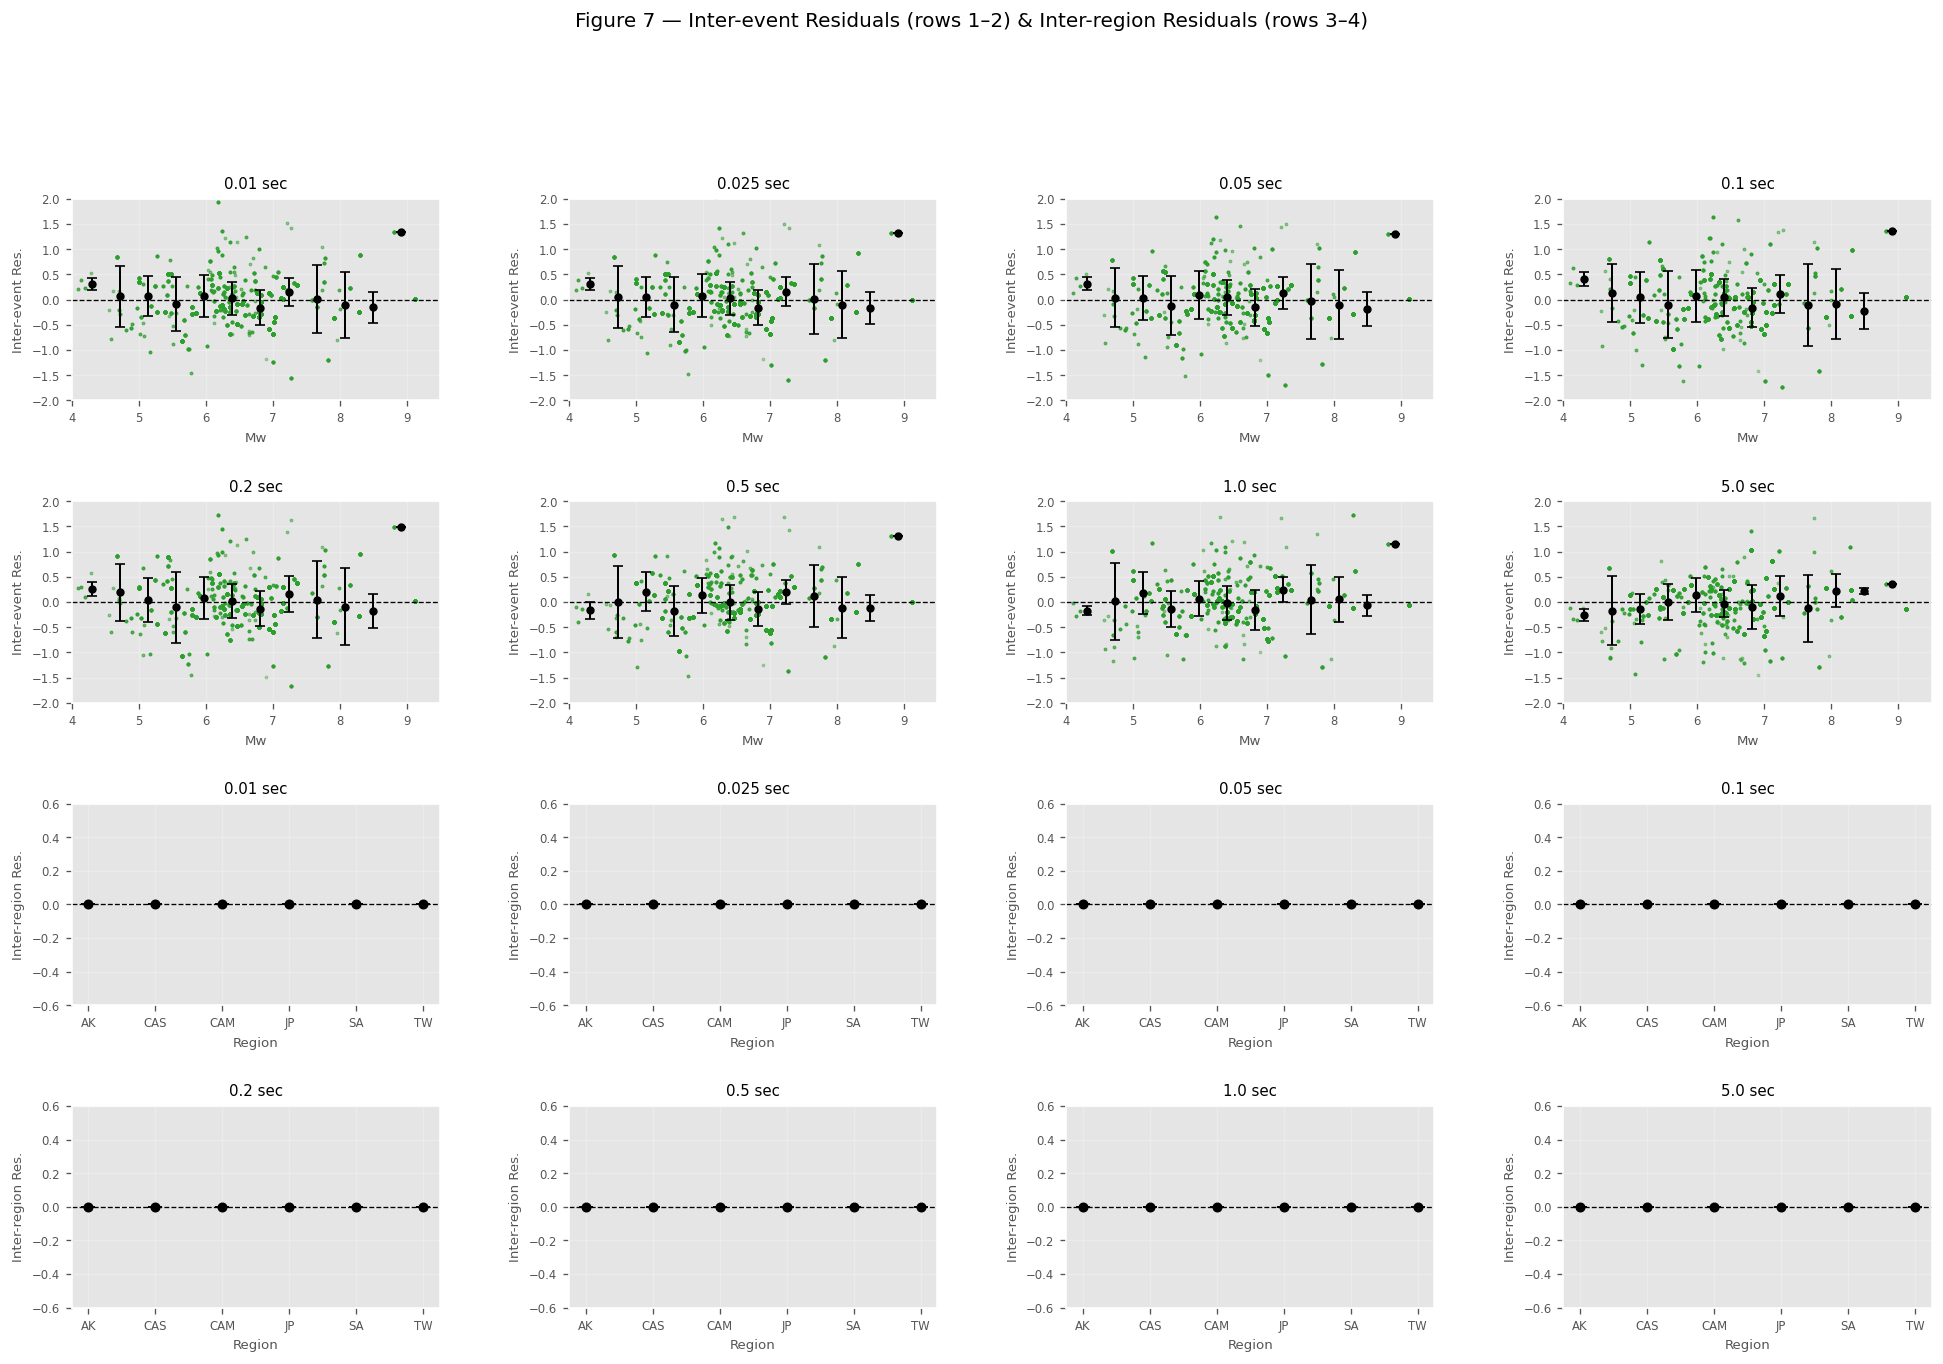

Saved: fig7_inter_residuals.png


In [16]:
SEL_T  = [0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1.0, 5.0]
SEL_IDX = [get_output_idx(t) for t in SEL_T]

def bin_stats(x, y, n_bins=10, pctile=True):
    """Return (bin_center, bin_mean, bin_std) for scatter binning."""
    if pctile:
        edges = np.percentile(x, np.linspace(5, 95, n_bins+1))
    else:
        edges = np.linspace(x.min(), x.max(), n_bins+1)
    centers, means, stds = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x < hi)
        if m.sum() >= 3:
            centers.append((lo+hi)/2); means.append(y[m].mean()); stds.append(y[m].std())
    return np.array(centers), np.array(means), np.array(stds)

fig = plt.figure(figsize=(20, 12))
gs  = GridSpec(4, 4, figure=fig, hspace=0.5, wspace=0.35)

for col, (t, idx) in enumerate(zip(SEL_T, SEL_IDX)):
    row_id = col // 4
    col_id = col % 4
    Be  = me_results[idx]['Be']
    Rr  = me_results[idx]['Rr']

    # ── Rows 0–1: inter-event vs Mw
    ax = fig.add_subplot(gs[row_id, col_id])
    ax.scatter(MW_ALL, Be, s=3, alpha=0.2, color='#2ca02c', rasterized=True)
    cx, cm, cs = bin_stats(MW_ALL, Be, n_bins=12, pctile=False)
    ax.errorbar(cx, cm, yerr=cs, fmt='ko', ms=4, capsize=3, lw=1.2, zorder=5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlim(4, 9.5); ax.set_ylim(-2, 2)
    ax.set_xlabel('Mw', fontsize=8); ax.set_ylabel('Inter-event Res.', fontsize=8)
    ax.set_title(f'{t} sec', fontsize=9); ax.grid(alpha=0.25)
    ax.tick_params(labelsize=7)

    # ── Rows 2–3: inter-region vs region
    ax2 = fig.add_subplot(gs[row_id+2, col_id])
    reg_labels = [REGION_NAMES[r] for r in sorted(REGION_NAMES)]
    for rg_id in sorted(REGION_NAMES.keys()):
        m = REGION_IDS == rg_id
        if not m.any(): continue
        ax2.scatter([REGION_NAMES[rg_id]]*m.sum(), Rr[m], s=4, alpha=0.25,
                    color=REGION_COLORS[rg_id], rasterized=True)
        ax2.errorbar(REGION_NAMES[rg_id], Rr[m].mean(), yerr=Rr[m].std(),
                     fmt='o', color='k', ms=5, capsize=4, lw=1.2, zorder=5)
    ax2.axhline(0, color='k', lw=0.8, ls='--')
    ax2.set_ylim(-0.6, 0.6)
    ax2.set_xlabel('Region', fontsize=8); ax2.set_ylabel('Inter-region Res.', fontsize=8)
    ax2.set_title(f'{t} sec', fontsize=9); ax2.grid(alpha=0.25)
    ax2.tick_params(labelsize=7)

fig.suptitle('Figure 7 — Inter-event Residuals (rows 1–2) & Inter-region Residuals (rows 3–4)',
             fontsize=12, y=1.01)
plt.savefig('fig7_inter_residuals.png', bbox_inches='tight')
plt.show()
print("Saved: fig7_inter_residuals.png")

## Cell 17 — Figure 8: Intra-event Residuals vs Distance & Vs30

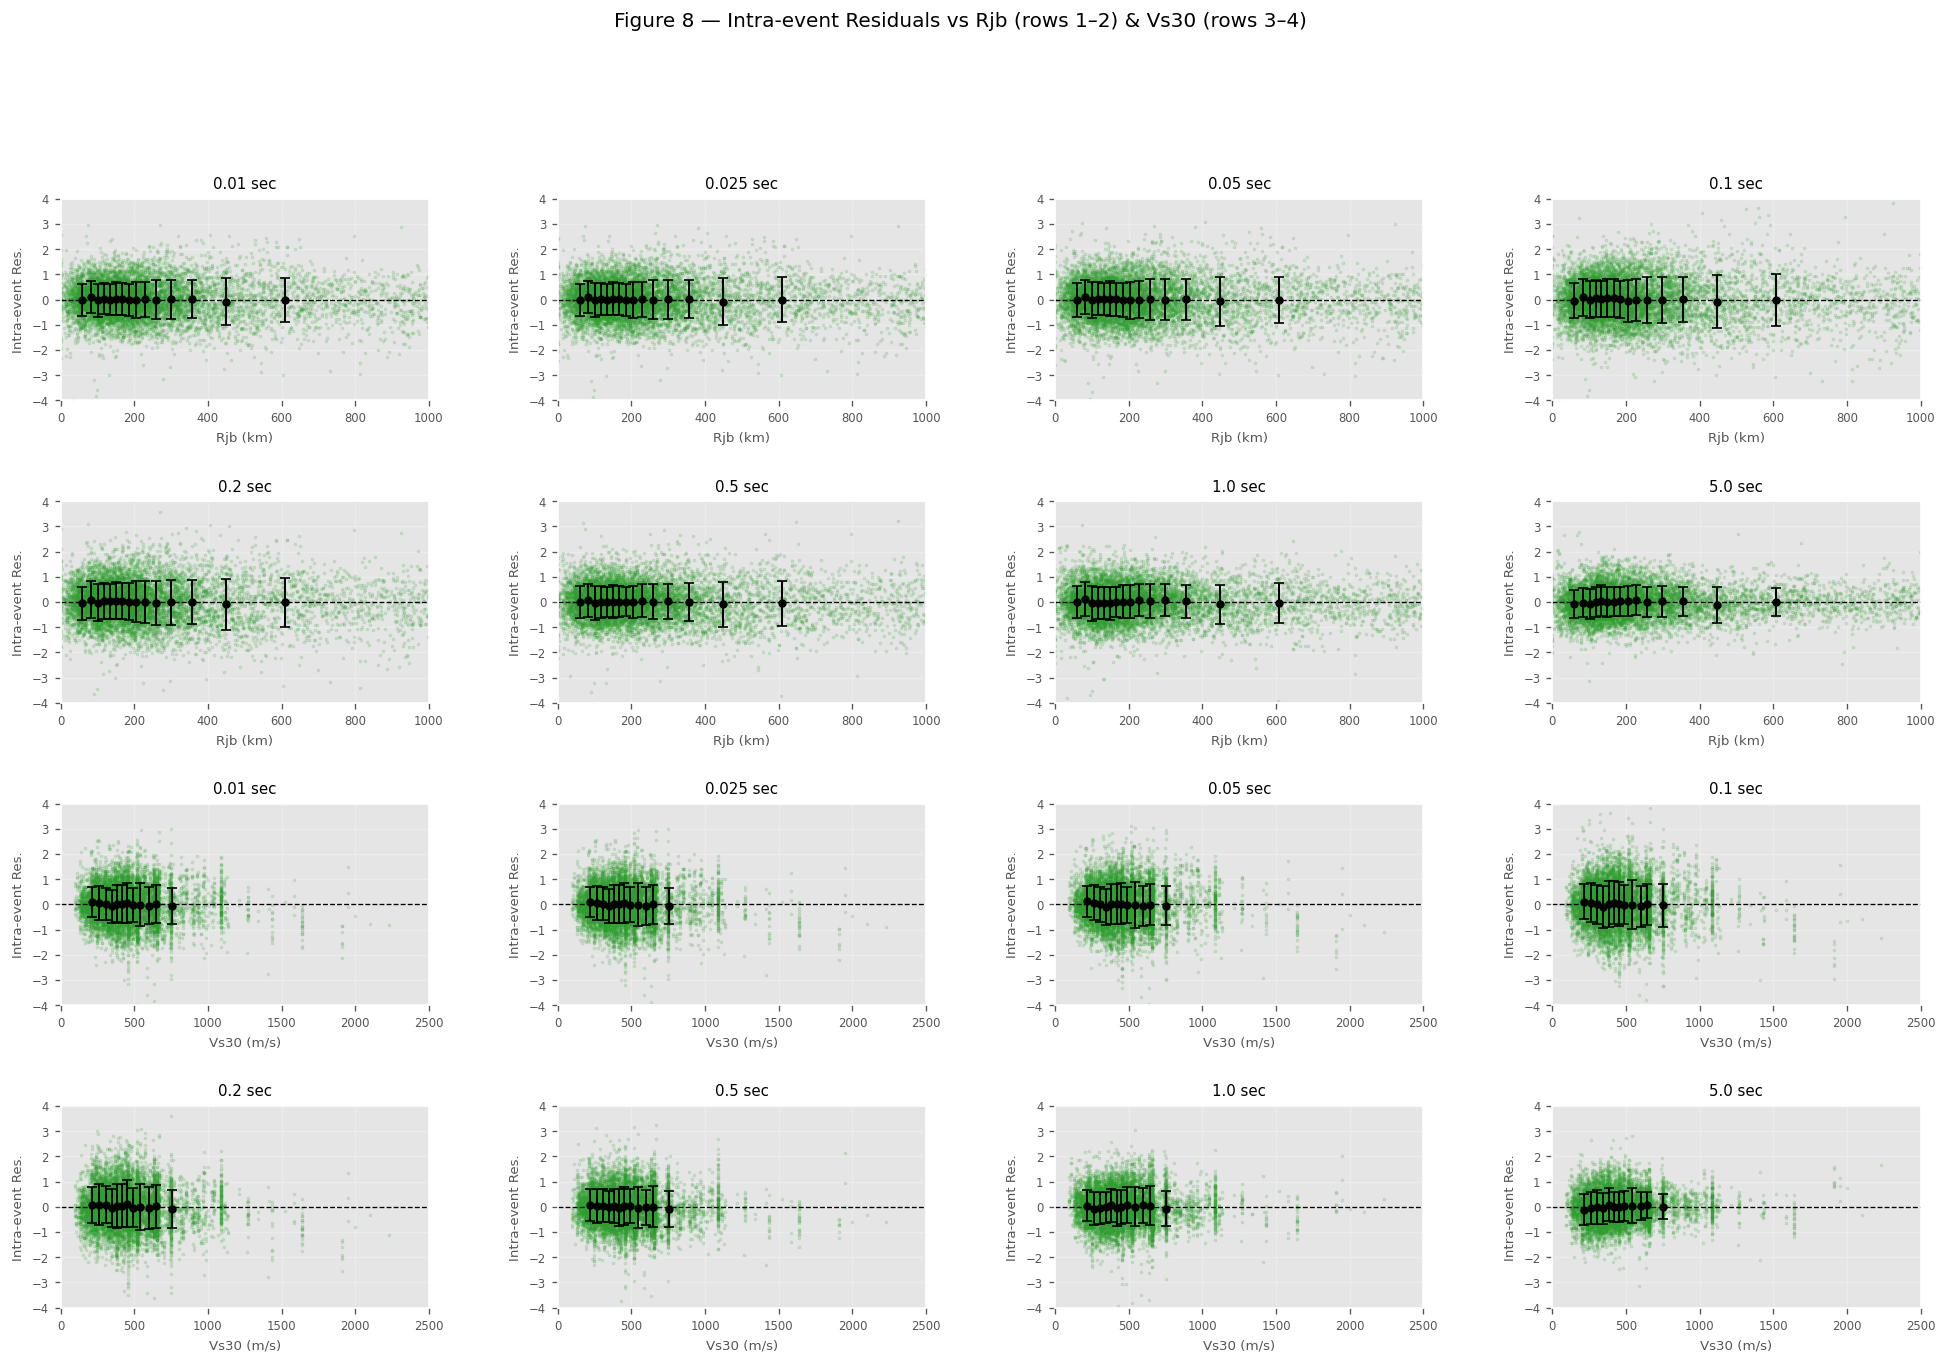

Saved: fig8_intra_residuals.png


In [17]:
fig = plt.figure(figsize=(20, 12))
gs  = GridSpec(4, 4, figure=fig, hspace=0.5, wspace=0.35)

for col, (t, idx) in enumerate(zip(SEL_T, SEL_IDX)):
    row_id = col // 4
    col_id = col % 4
    Wes = me_results[idx]['Wes']

    # ── Rows 0–1: vs Rjb
    ax = fig.add_subplot(gs[row_id, col_id])
    ax.scatter(RJB_ALL, Wes, s=3, alpha=0.15, color='#2ca02c', rasterized=True)
    cx, cm, cs = bin_stats(RJB_ALL, Wes, n_bins=15)
    ax.errorbar(cx, cm, yerr=cs, fmt='ko', ms=4, capsize=3, lw=1.2, zorder=5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlim(0, 1000); ax.set_ylim(-4, 4)
    ax.set_xlabel('Rjb (km)', fontsize=8); ax.set_ylabel('Intra-event Res.', fontsize=8)
    ax.set_title(f'{t} sec', fontsize=9); ax.grid(alpha=0.25)
    ax.tick_params(labelsize=7)

    # ── Rows 2–3: vs Vs30
    ax2 = fig.add_subplot(gs[row_id+2, col_id])
    ax2.scatter(VS30_ALL, Wes, s=3, alpha=0.15, color='#2ca02c', rasterized=True)
    cx2, cm2, cs2 = bin_stats(VS30_ALL, Wes, n_bins=12)
    ax2.errorbar(cx2, cm2, yerr=cs2, fmt='ko', ms=4, capsize=3, lw=1.2, zorder=5)
    ax2.axhline(0, color='k', lw=0.8, ls='--')
    ax2.set_xlim(0, 2500); ax2.set_ylim(-4, 4)
    ax2.set_xlabel('Vs30 (m/s)', fontsize=8); ax2.set_ylabel('Intra-event Res.', fontsize=8)
    ax2.set_title(f'{t} sec', fontsize=9); ax2.grid(alpha=0.25)
    ax2.tick_params(labelsize=7)

fig.suptitle('Figure 8 — Intra-event Residuals vs Rjb (rows 1–2) & Vs30 (rows 3–4)',
             fontsize=12, y=1.01)
plt.savefig('fig8_intra_residuals.png', bbox_inches='tight')
plt.show()
print("Saved: fig8_intra_residuals.png")

## Cell 18 — Figure 9: PGA, PGV, PGD Residuals

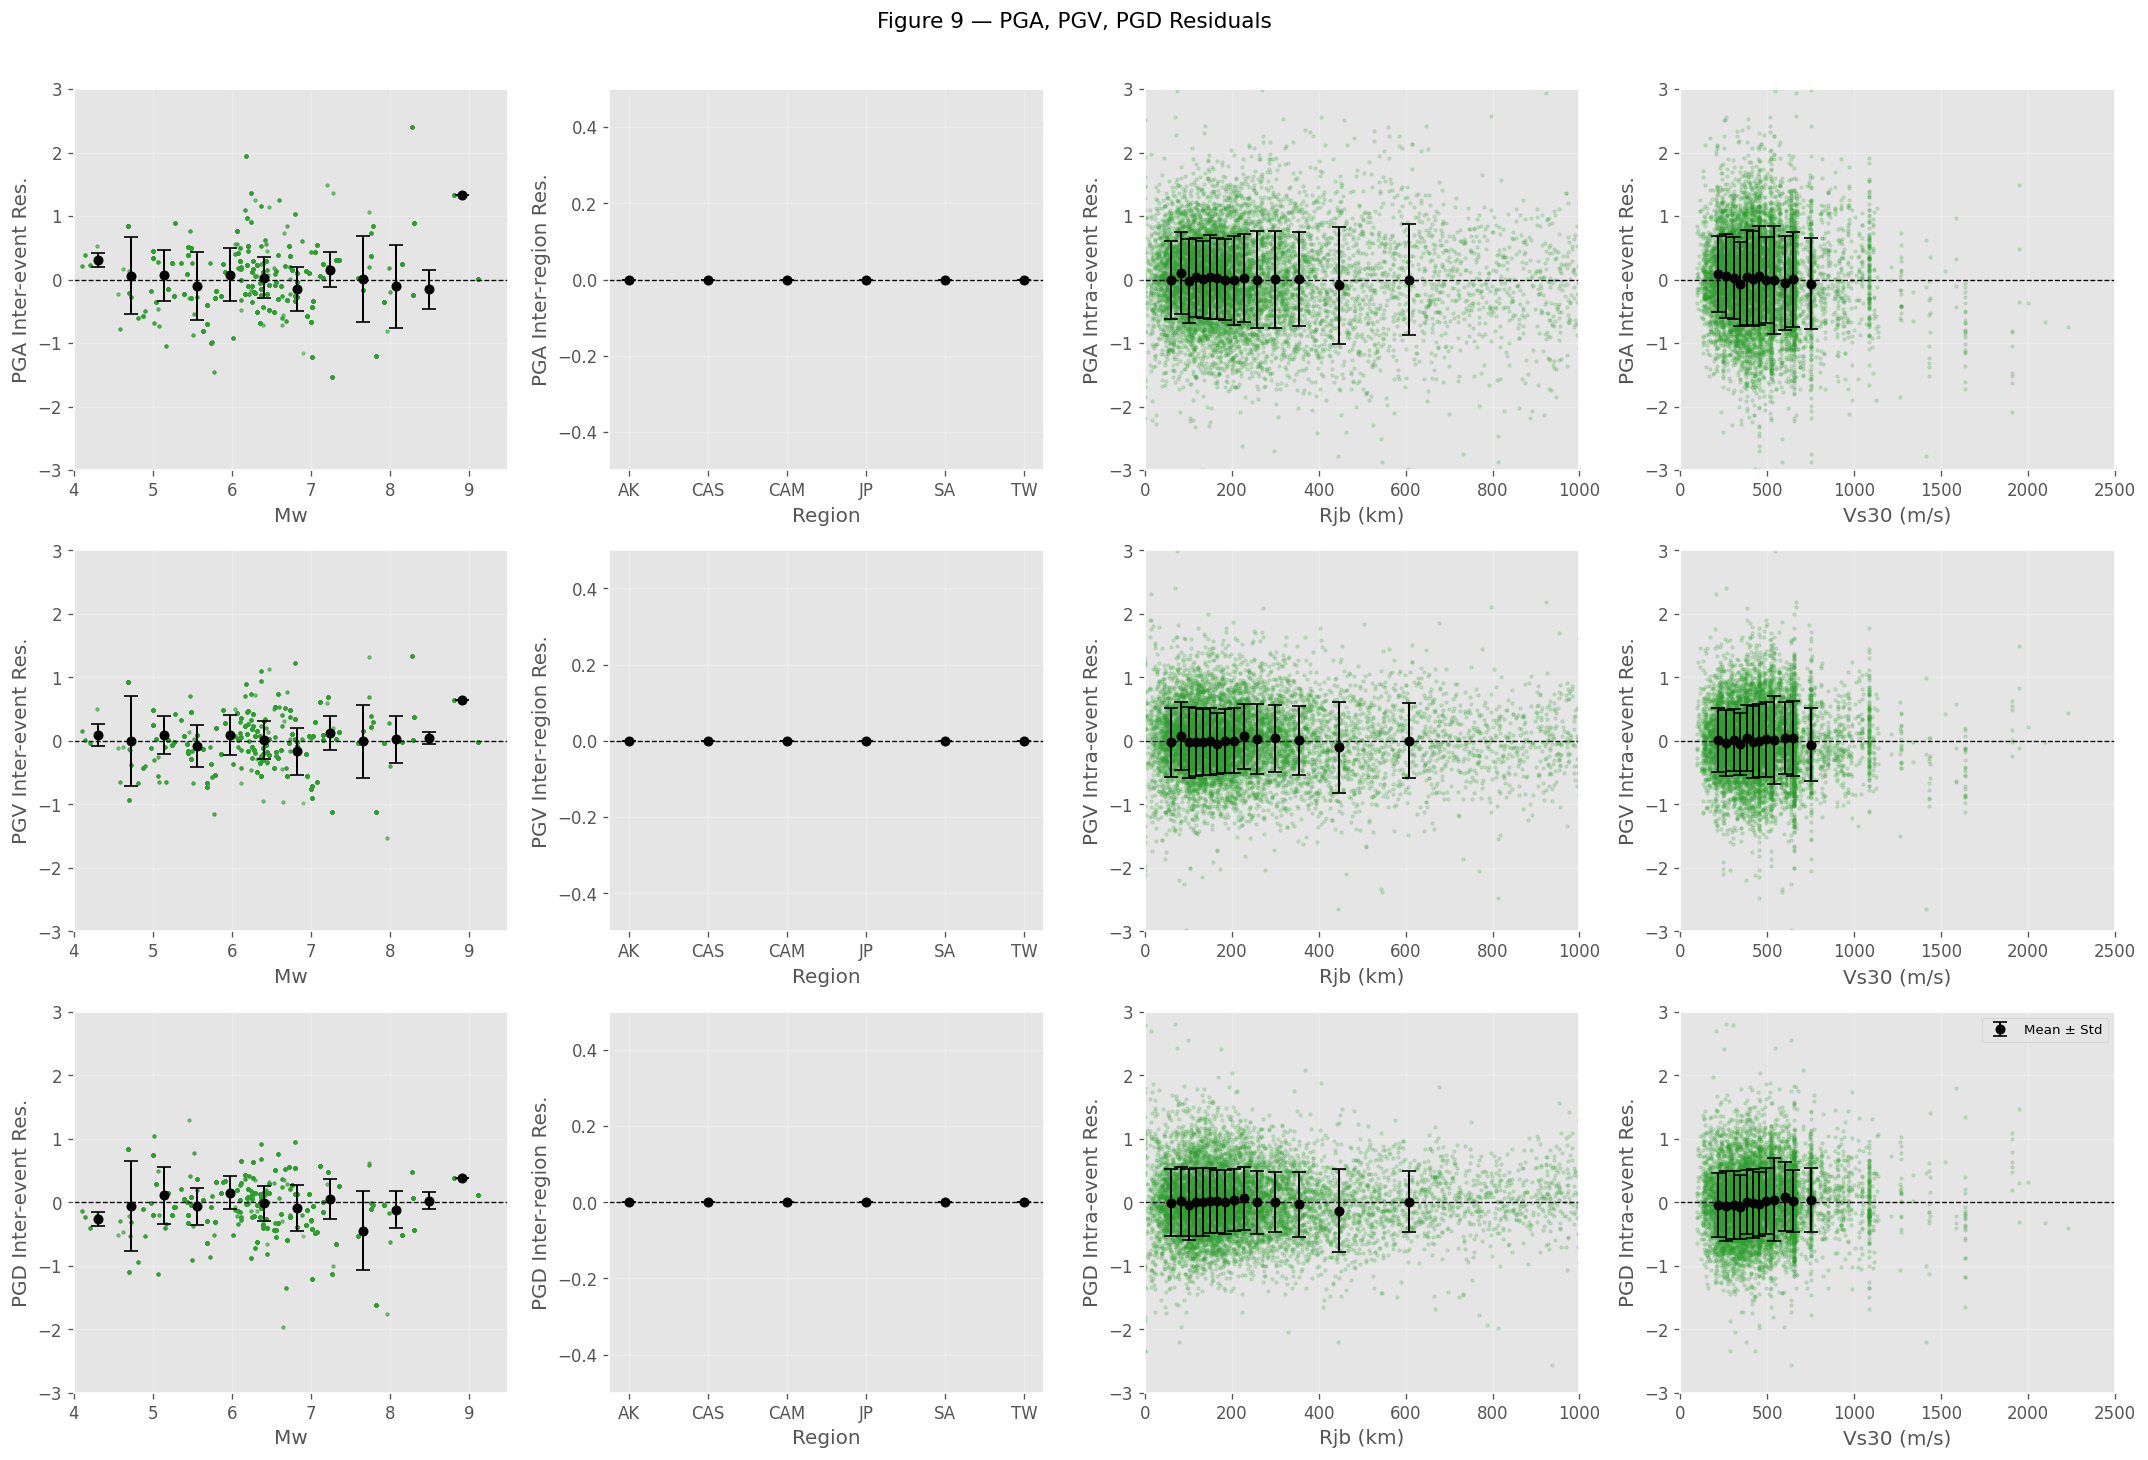

Saved: fig9_pga_pgv_pgd_residuals.png


In [18]:
PEAK_PARAMS = [('PGA', 105), ('PGV', 106), ('PGD', 107)]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Figure 9 — PGA, PGV, PGD Residuals', fontsize=13, y=1.01)

for row, (label, idx) in enumerate(PEAK_PARAMS):
    Be  = me_results[idx]['Be']
    Rr  = me_results[idx]['Rr']
    Wes = me_results[idx]['Wes']

    # Col 0: inter-event vs Mw
    ax = axes[row][0]
    ax.scatter(MW_ALL, Be, s=4, alpha=0.25, color='#2ca02c', rasterized=True)
    cx, cm, cs = bin_stats(MW_ALL, Be, n_bins=12, pctile=False)
    ax.errorbar(cx, cm, yerr=cs, fmt='ko', ms=5, capsize=4, lw=1.2, zorder=5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Mw'); ax.set_ylabel(f'{label} Inter-event Res.')
    ax.set_xlim(4, 9.5); ax.set_ylim(-3, 3); ax.grid(alpha=0.25)

    # Col 1: inter-region per region
    ax = axes[row][1]
    for rg_id in sorted(REGION_NAMES.keys()):
        m = REGION_IDS == rg_id
        if not m.any(): continue
        ax.scatter([REGION_NAMES[rg_id]]*m.sum(), Rr[m], s=4, alpha=0.25,
                   color=REGION_COLORS[rg_id], rasterized=True)
        ax.errorbar(REGION_NAMES[rg_id], Rr[m].mean(), yerr=Rr[m].std(),
                    fmt='o', color='k', ms=5, capsize=4, lw=1.2, zorder=5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Region'); ax.set_ylabel(f'{label} Inter-region Res.')
    ax.set_ylim(-0.5, 0.5); ax.grid(alpha=0.25)

    # Col 2: intra-event vs Rjb
    ax = axes[row][2]
    ax.scatter(RJB_ALL, Wes, s=4, alpha=0.2, color='#2ca02c', rasterized=True)
    cx, cm, cs = bin_stats(RJB_ALL, Wes, n_bins=15)
    ax.errorbar(cx, cm, yerr=cs, fmt='ko', ms=5, capsize=4, lw=1.2, zorder=5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Rjb (km)'); ax.set_ylabel(f'{label} Intra-event Res.')
    ax.set_xlim(0, 1000); ax.set_ylim(-3, 3); ax.grid(alpha=0.25)

    # Col 3: intra-event vs Vs30
    ax = axes[row][3]
    ax.scatter(VS30_ALL, Wes, s=4, alpha=0.2, color='#2ca02c', rasterized=True)
    cx, cm, cs = bin_stats(VS30_ALL, Wes, n_bins=12)
    ax.errorbar(cx, cm, yerr=cs, fmt='ko', ms=5, capsize=4, lw=1.2,
                zorder=5, label='Mean ± Std')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Vs30 (m/s)'); ax.set_ylabel(f'{label} Intra-event Res.')
    ax.set_xlim(0, 2500); ax.set_ylim(-3, 3); ax.grid(alpha=0.25)
    if row == 2:
        ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('fig9_pga_pgv_pgd_residuals.png', bbox_inches='tight')
plt.show()
print("Saved: fig9_pga_pgv_pgd_residuals.png")

## Cell 19 — Prediction Helper Function

In [19]:
def predict_gmpe(Mw, Rjb_km, Ztor_km, Vs30_ms, region_flag):
    """
    Predict PSA, PGA, PGV, PGD using the trained ANN-GMPE.

    Parameters
    ----------
    Mw          : float — moment magnitude
    Rjb_km      : float or array-like — Joyner-Boore distance (km)
    Ztor_km     : float — depth to top of rupture (km)
    Vs30_ms     : float — shear wave velocity (m/s)
    region_flag : int   — AK=1, CAS=2, CAM=3, JP=4, SA=5, TW=6

    Returns
    -------
    psa_g   : ndarray (n_dist, 105) — PSA in g
    pga_g   : ndarray (n_dist,)     — PGA in g
    pgv_cms : ndarray (n_dist,)     — PGV in cm/s
    pgd_cm  : ndarray (n_dist,)     — PGD in cm
    """
    R = np.atleast_1d(np.asarray(Rjb_km, dtype=float))
    n = len(R)
    X_in = np.column_stack([
        np.full(n, Mw),
        R,
        np.log(np.maximum(R, 0.01)),
        np.full(n, Ztor_km),
        np.full(n, np.log(Vs30_ms)),
        np.full(n, region_flag),
    ])
    X_sc  = scaler_X.transform(X_in)
    Y_sc  = model_final.predict(X_sc, verbose=0)
    Y_ln  = scaler_Y.inverse_transform(Y_sc)
    Y_out = np.exp(Y_ln)
    return Y_out[:, :105], Y_out[:, 105], Y_out[:, 106], Y_out[:, 107]

# Quick test
psa, pga, pgv, pgd = predict_gmpe(Mw=8, Rjb_km=[50, 200, 500],
                                    Ztor_km=20, Vs30_ms=400, region_flag=4)
print("Sample prediction (Mw=8, Vs30=400, ZTOR=20, JP, interface):")
print(f"  Rjb=50  km → PGA={pga[0]:.4f} g, PGV={pgv[0]:.3f} cm/s, PGD={pgd[0]:.3f} cm")
print(f"  Rjb=200 km → PGA={pga[1]:.4f} g, PGV={pgv[1]:.3f} cm/s, PGD={pgd[1]:.3f} cm")
print(f"  Rjb=500 km → PGA={pga[2]:.4f} g, PGV={pgv[2]:.3f} cm/s, PGD={pgd[2]:.3f} cm")

Sample prediction (Mw=8, Vs30=400, ZTOR=20, JP, interface):
  Rjb=50  km → PGA=0.2871 g, PGV=19.799 cm/s, PGD=17.164 cm
  Rjb=200 km → PGA=0.0219 g, PGV=3.417 cm/s, PGD=5.763 cm
  Rjb=500 km → PGA=0.0024 g, PGV=0.829 cm/s, PGD=2.670 cm


## Cell 20 — Figures 10 & 11: Interface Events — Sa vs Rjb (Mw=8)

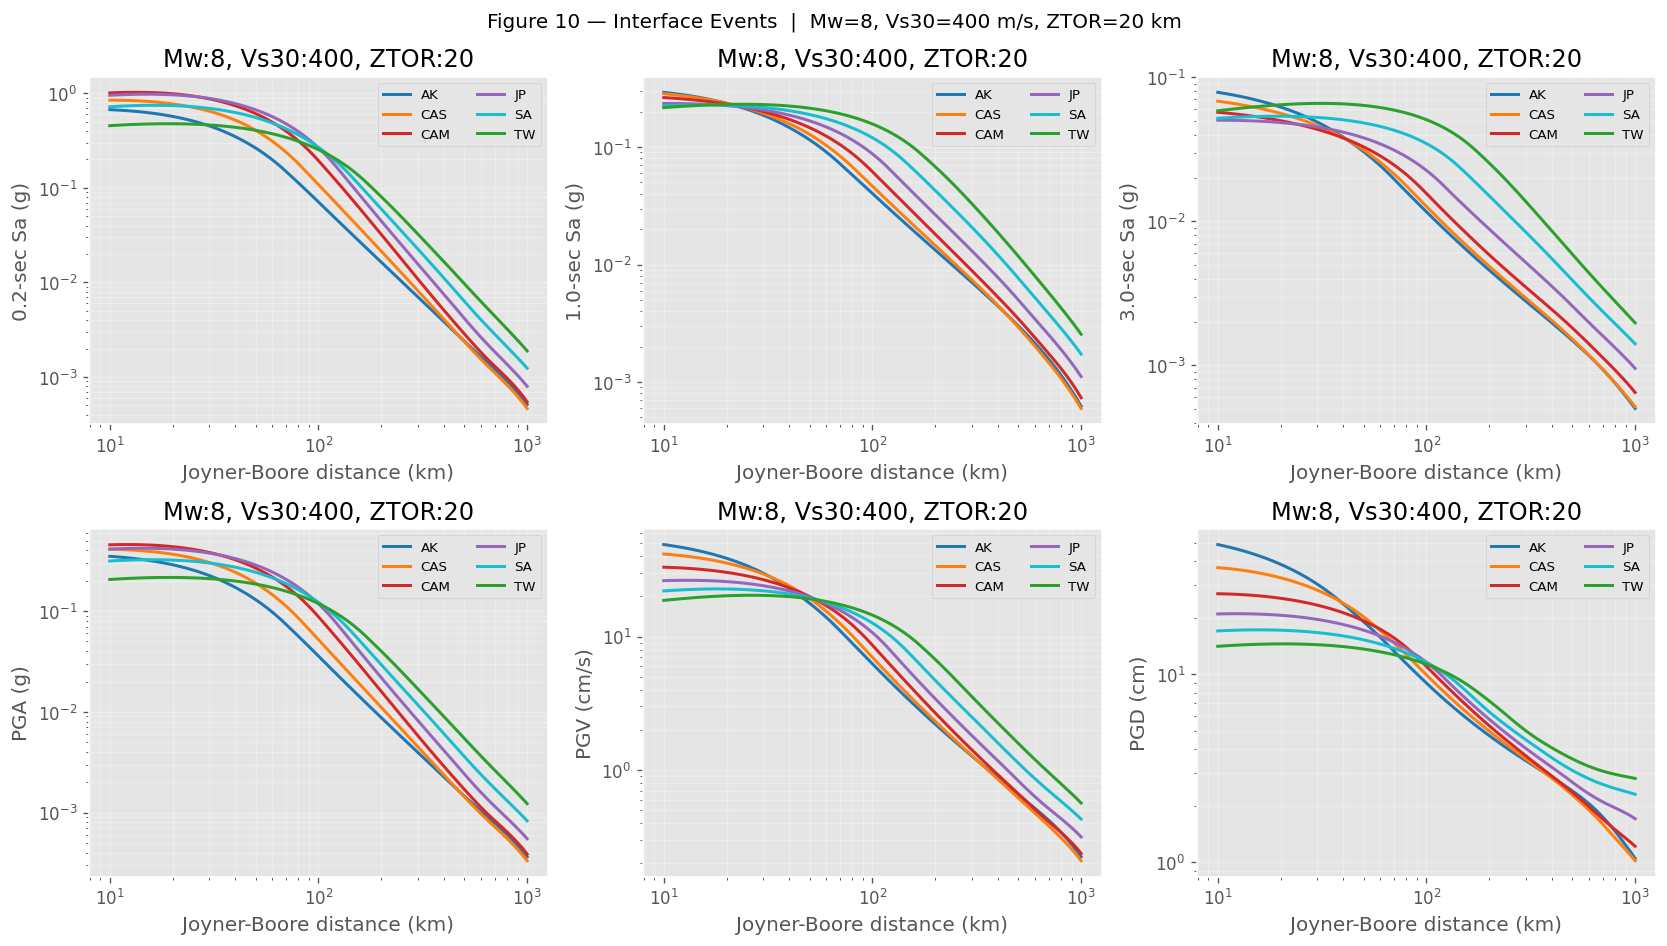

Saved: fig10_interface_Mw8_Vs400.png


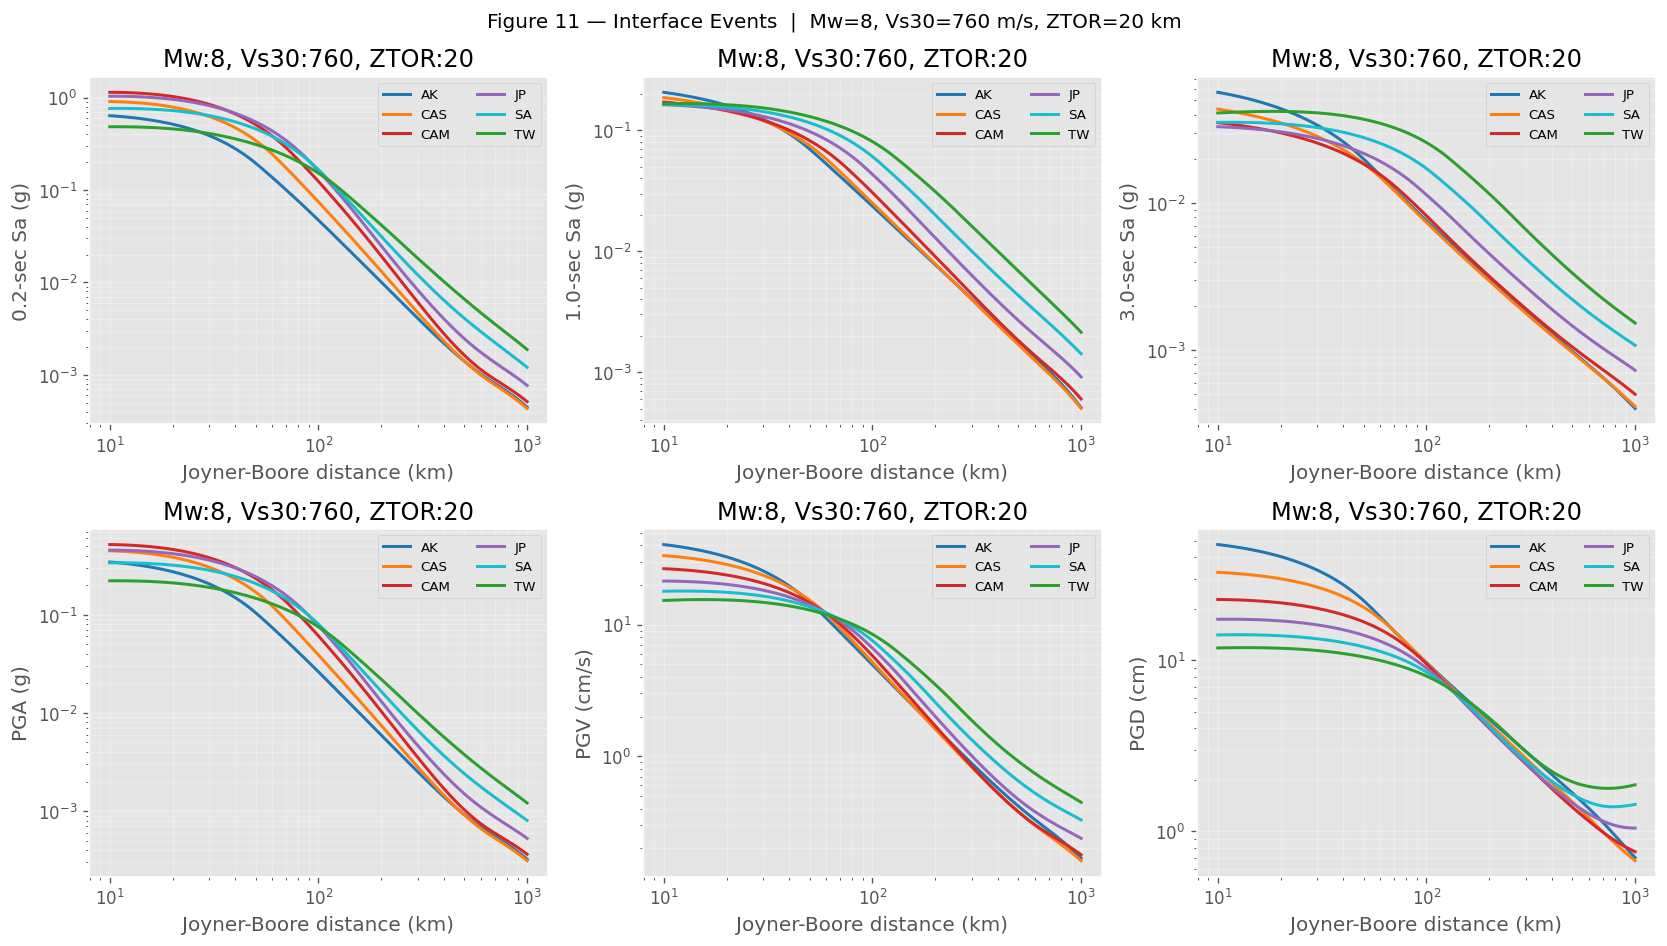

Saved: fig11_interface_Mw8_Vs760.png


In [20]:
R_DIST = np.logspace(np.log10(10), np.log10(1000), 100)
T_PLOT = np.array(PERIOD_VALUES)

def plot_scenario_vs_Rjb(Mw, Vs30, Ztor, event_type, fig_num, fname):
    """6-panel figure: [0.2s, 1s, 3s Sa] + [PGA, PGV, PGD] vs Rjb for all regions"""
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(
        f'Figure {fig_num} — {event_type}  |  Mw={Mw}, Vs30={Vs30} m/s, ZTOR={Ztor} km',
        fontsize=12)

    target_T   = [0.2, 1.0, 3.0]
    target_idx = [PERIOD_VALUES.index(t) for t in target_T]

    # Row 1: PSA at 3 periods
    for j, (tp, pi) in enumerate(zip(target_T, target_idx)):
        ax = axes[0][j]
        for rg in range(1, 7):
            psa, _, _, _ = predict_gmpe(Mw, R_DIST, Ztor, Vs30, rg)
            ax.loglog(R_DIST, psa[:, pi], color=REGION_COLORS[rg],
                      label=REGION_NAMES[rg], lw=1.8)
        ax.set_xlabel('Joyner-Boore distance (km)')
        ax.set_ylabel(f'{tp}-sec Sa (g)')
        ax.set_title(f'Mw:{Mw}, Vs30:{Vs30}, ZTOR:{Ztor}')
        ax.grid(True, which='both', alpha=0.3)
        ax.legend(fontsize=8, ncol=2)

    # Row 2: PGA, PGV, PGD
    for j, (lbl, getter) in enumerate(zip(
            ['PGA (g)', 'PGV (cm/s)', 'PGD (cm)'],
            [lambda p,_,__,___: p, lambda _,v,__,___: v, lambda _,__,d,___: d])):
        ax = axes[1][j]
        for rg in range(1, 7):
            out = predict_gmpe(Mw, R_DIST, Ztor, Vs30, rg)
            # get the right output
            vals = [out[1], out[2], out[3]][j]
            ax.loglog(R_DIST, vals, color=REGION_COLORS[rg],
                      label=REGION_NAMES[rg], lw=1.8)
        ax.set_xlabel('Joyner-Boore distance (km)')
        ax.set_ylabel(lbl)
        ax.set_title(f'Mw:{Mw}, Vs30:{Vs30}, ZTOR:{Ztor}')
        ax.grid(True, which='both', alpha=0.3)
        ax.legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.savefig(fname)
    plt.show()
    print(f"Saved: {fname}")

# Figure 10: Interface  Mw=8, Vs30=400, ZTOR=20
plot_scenario_vs_Rjb(8, 400, 20, 'Interface Events', 10, 'fig10_interface_Mw8_Vs400.png')
# Figure 11: Interface  Mw=8, Vs30=760, ZTOR=20
plot_scenario_vs_Rjb(8, 760, 20, 'Interface Events', 11, 'fig11_interface_Mw8_Vs760.png')

## Cell 21 — Figures 12 & 13: Intraslab Events — Sa vs Rjb (Mw=7)

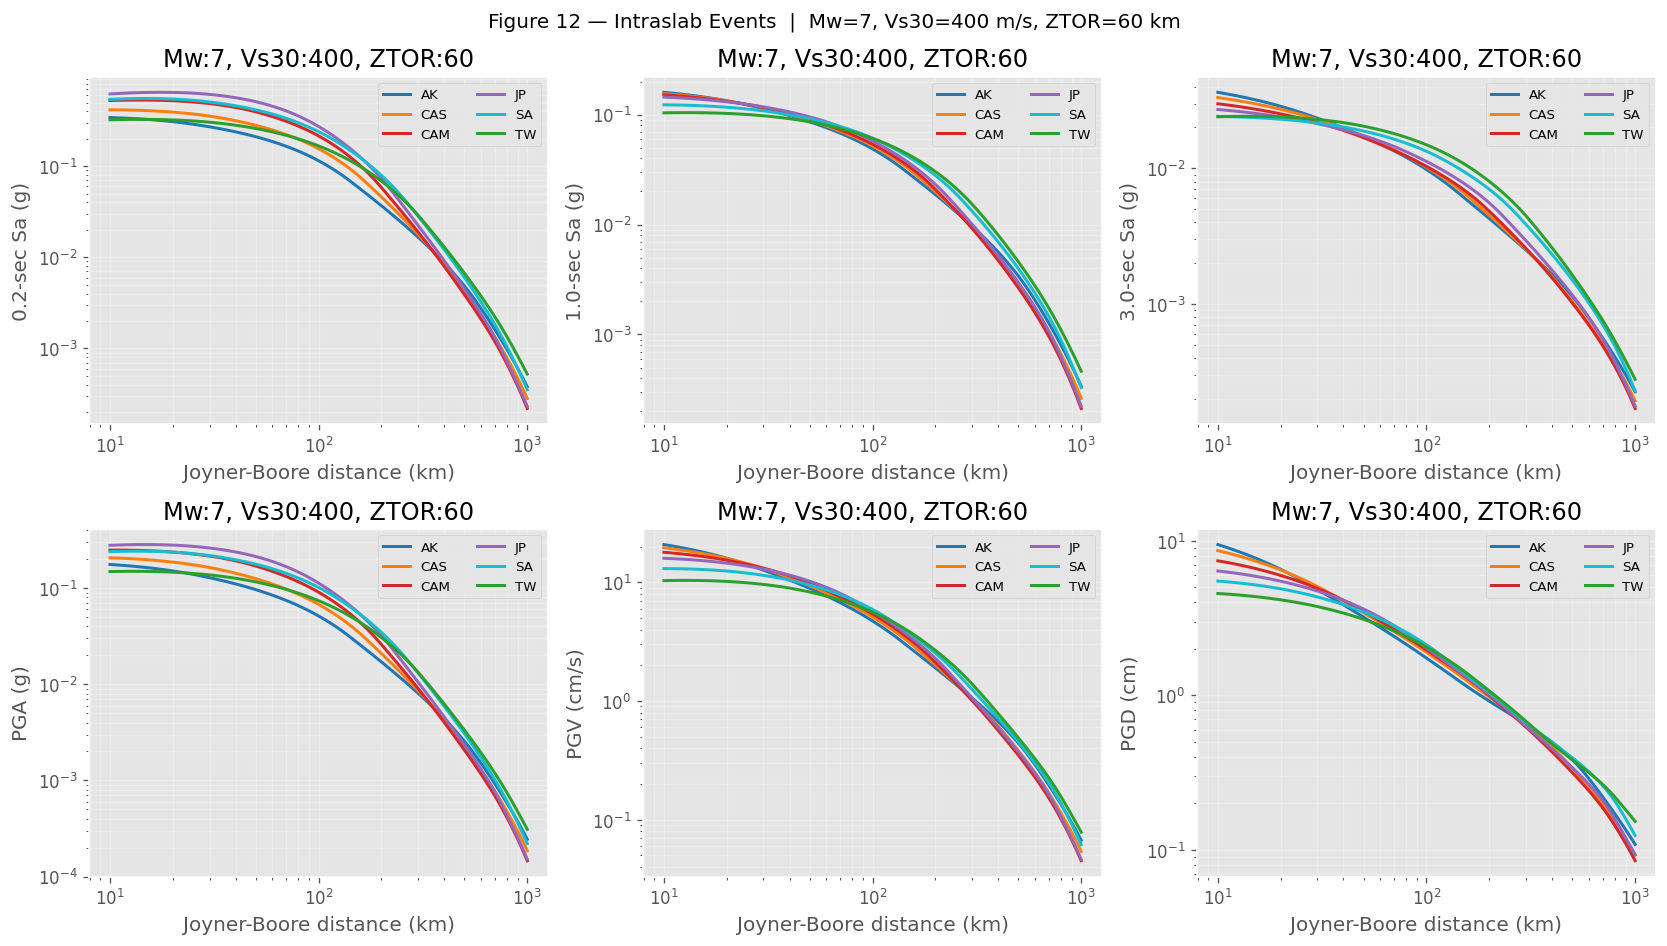

Saved: fig12_intraslab_Mw7_Vs400.png


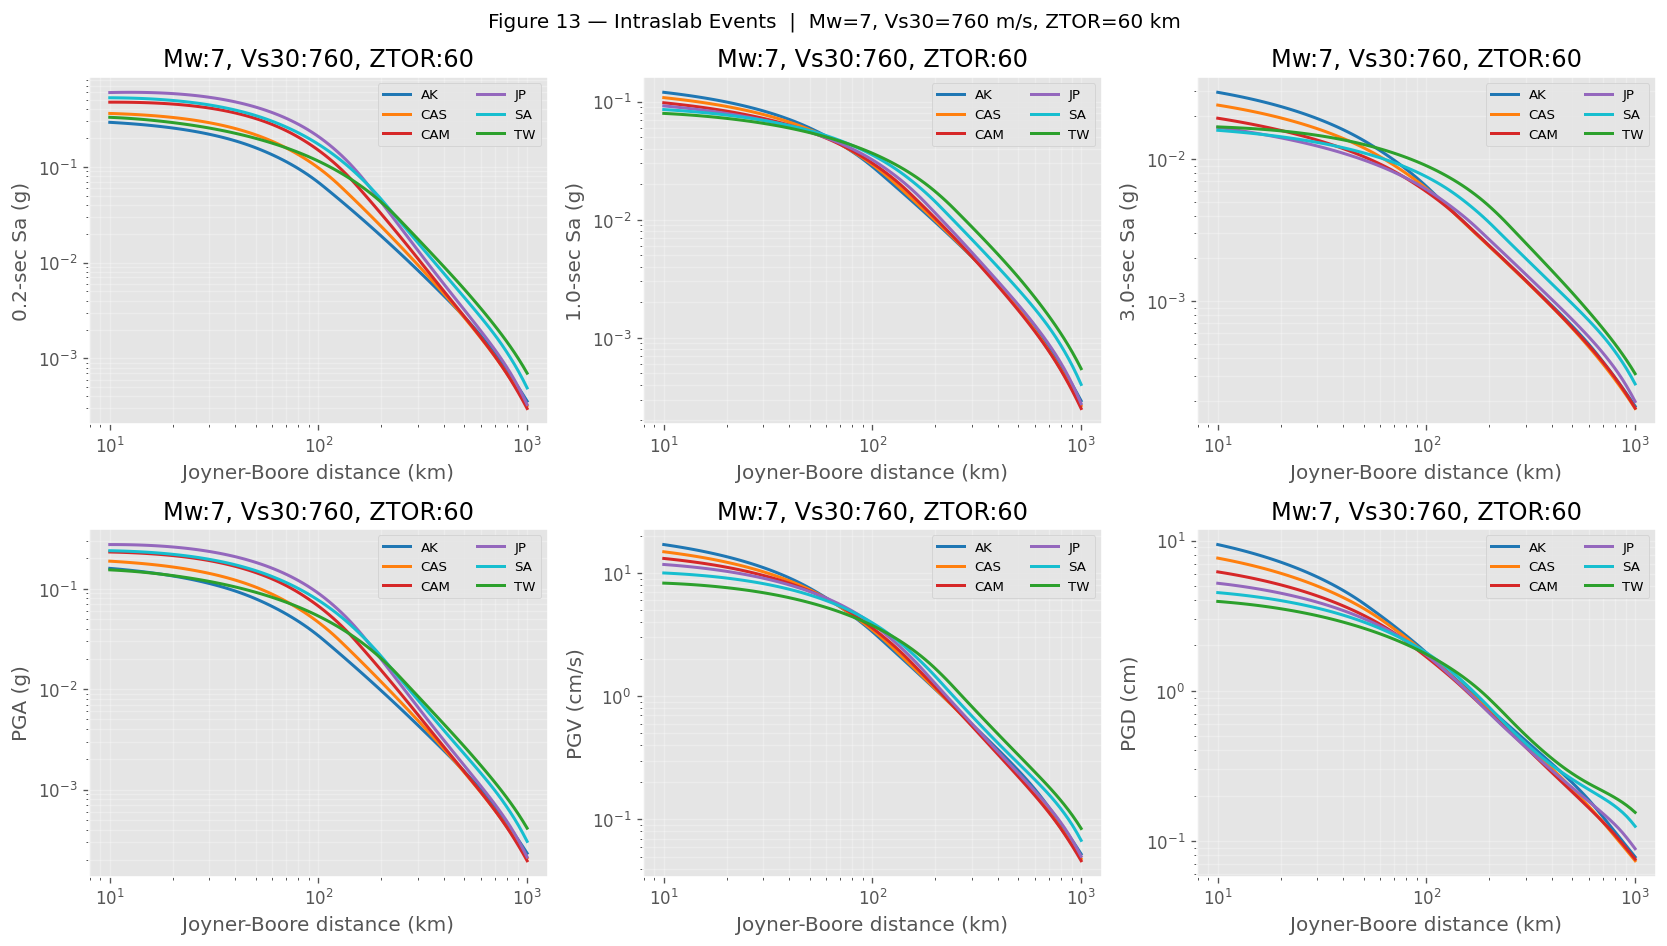

Saved: fig13_intraslab_Mw7_Vs760.png


In [21]:
# Figure 12: Intraslab  Mw=7, Vs30=400, ZTOR=60
plot_scenario_vs_Rjb(7, 400, 60, 'Intraslab Events', 12, 'fig12_intraslab_Mw7_Vs400.png')
# Figure 13: Intraslab  Mw=7, Vs30=760, ZTOR=60
plot_scenario_vs_Rjb(7, 760, 60, 'Intraslab Events', 13, 'fig13_intraslab_Mw7_Vs760.png')

## Cell 22 — Figures 14 & 15: Sa vs Period for All Regions

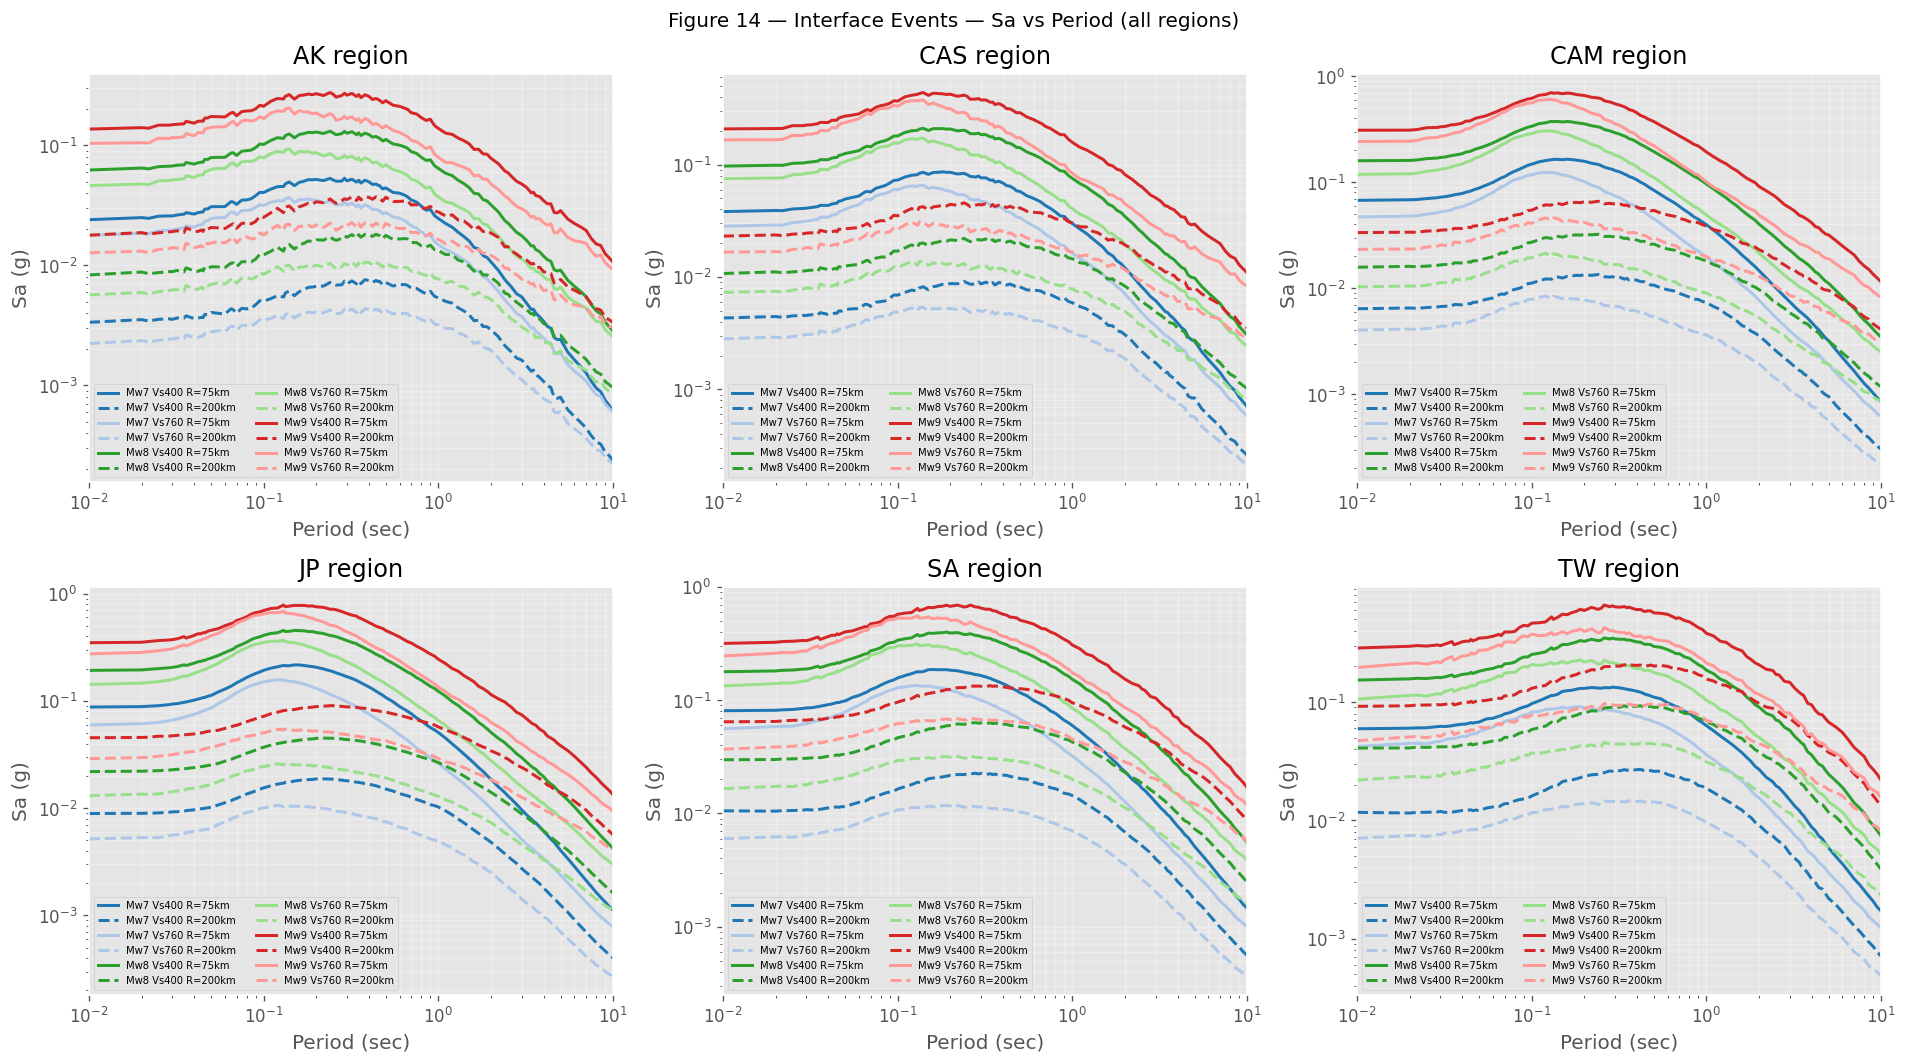

Saved: fig14_spectrum_interface.png


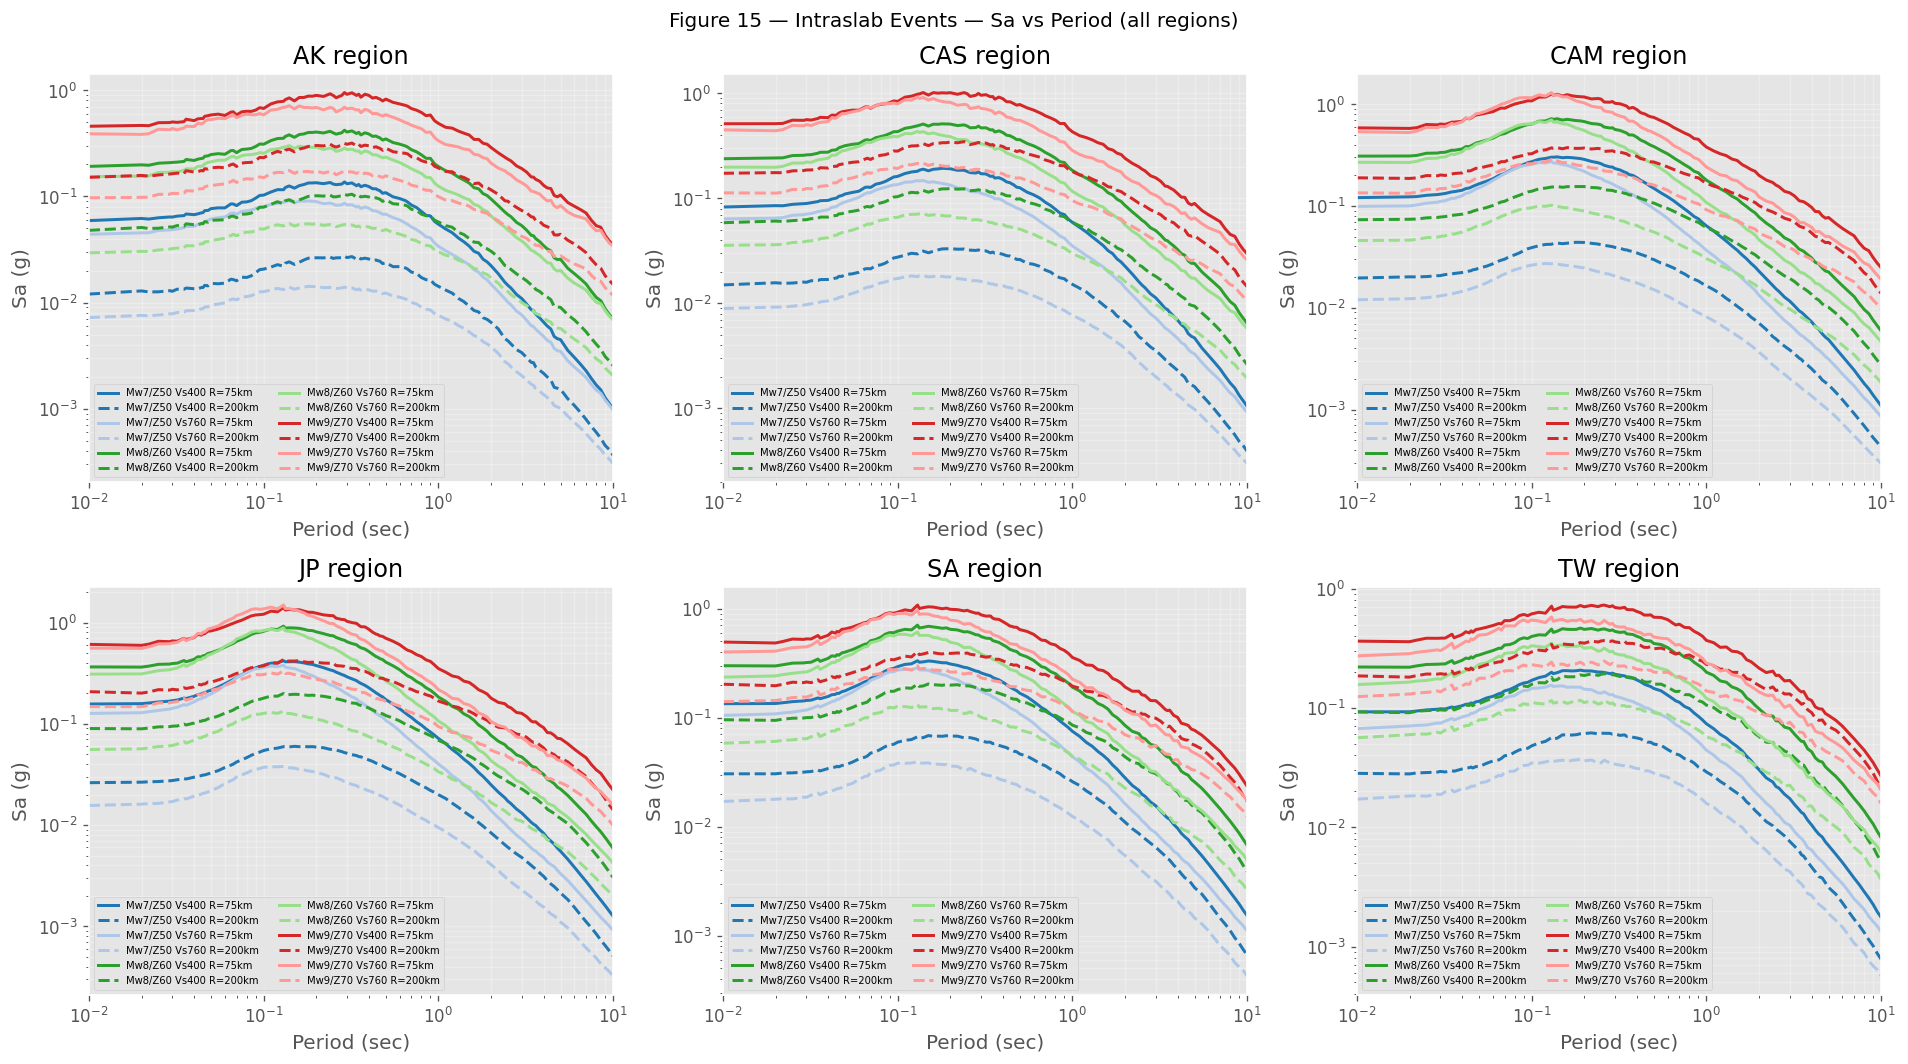

Saved: fig15_spectrum_intraslab.png


In [22]:
def plot_spectrum_vs_period(scenarios, event_type, fig_num, fname):
    """
    scenarios: list of (Mw, Ztor, Vs30, R_thick, R_dot, color, label)
    Plots Sa spectra at R=75 (solid) and R=200 (dashed) km for all scenarios.
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f'Figure {fig_num} — {event_type} — Sa vs Period (all regions)',
                 fontsize=12)

    # Row 0: Alaska; Row 1: other regions — or plot all 6 by Mw group
    # Here we show Sa(T) for one region per panel across Mw scenarios
    panels = [(1,'AK'),(2,'CAS'),(3,'CAM'),(4,'JP'),(5,'SA'),(6,'TW')]

    for ax_i, (rg, rg_name) in enumerate(panels):
        r, c = divmod(ax_i, 3)
        ax   = axes[r][c]
        for (Mw, Zt, Vs, R1, R2, col, lbl) in scenarios:
            psa1, pga1, pgv1, pgd1 = predict_gmpe(Mw, R1, Zt, Vs, rg)
            psa2, pga2, pgv2, pgd2 = predict_gmpe(Mw, R2, Zt, Vs, rg)
            ax.loglog(T_PLOT, psa1[0], color=col, lw=1.8, ls='-',
                      label=f'{lbl} R={R1}km')
            ax.loglog(T_PLOT, psa2[0], color=col, lw=1.8, ls='--',
                      label=f'{lbl} R={R2}km')
        ax.set_xlabel('Period (sec)'); ax.set_ylabel('Sa (g)')
        ax.set_title(f'{rg_name} region')
        ax.set_xlim(0.01, 10)
        ax.grid(True, which='both', alpha=0.3)
        ax.legend(fontsize=6, ncol=2)

    plt.tight_layout()
    plt.savefig(fname)
    plt.show()
    print(f"Saved: {fname}")

# Figure 14: Interface scenarios (Mw 7,8,9 | ZTOR=20 | Vs30=400,760)
scenarios_int = [
    (7, 20, 400, 75, 200, '#1f77b4', 'Mw7 Vs400'),
    (7, 20, 760, 75, 200, '#aec7e8', 'Mw7 Vs760'),
    (8, 20, 400, 75, 200, '#2ca02c', 'Mw8 Vs400'),
    (8, 20, 760, 75, 200, '#98df8a', 'Mw8 Vs760'),
    (9, 20, 400, 75, 200, '#d62728', 'Mw9 Vs400'),
    (9, 20, 760, 75, 200, '#ff9896', 'Mw9 Vs760'),
]
plot_spectrum_vs_period(scenarios_int, 'Interface Events', 14, 'fig14_spectrum_interface.png')

# Figure 15: Intraslab scenarios (Mw/Ztor pairs: 7/50, 8/60, 9/70)
scenarios_slab = [
    (7, 50, 400, 75, 200, '#1f77b4', 'Mw7/Z50 Vs400'),
    (7, 50, 760, 75, 200, '#aec7e8', 'Mw7/Z50 Vs760'),
    (8, 60, 400, 75, 200, '#2ca02c', 'Mw8/Z60 Vs400'),
    (8, 60, 760, 75, 200, '#98df8a', 'Mw8/Z60 Vs760'),
    (9, 70, 400, 75, 200, '#d62728', 'Mw9/Z70 Vs400'),
    (9, 70, 760, 75, 200, '#ff9896', 'Mw9/Z70 Vs760'),
]
plot_spectrum_vs_period(scenarios_slab, 'Intraslab Events', 15, 'fig15_spectrum_intraslab.png')

## Cell 23 — Relative Importance Analysis (Section 3.4)

═════════════════════════════════════════════
  Relative Importance (ΔMSE)
═════════════════════════════════════════════
  Mw             : 0.830 ± 0.014  ██████████████████████████████
  RJB (km)       : 0.116 ± 0.002  ████
  ln(RJB)        : 0.466 ± 0.007  ████████████████
  ZTOR (km)      : 0.127 ± 0.003  ████
  ln(Vs30)       : 0.042 ± 0.001  █
  Region Flag    : 0.024 ± 0.001  

  Paper reports: Mw=4.9, RJB=0.29, ln(RJB)=4.04, ZTOR=0.74, ln(Vs30)=0.27, R=0.38


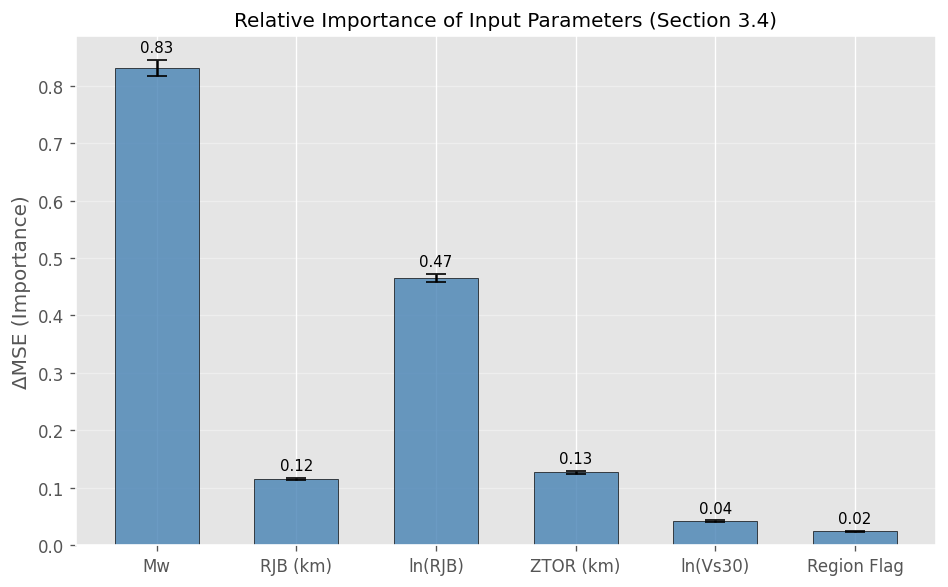

Saved: fig_relative_importance.png


In [23]:
N_REPEATS = 20
rng = np.random.default_rng(42)

baseline_mse = float(np.mean((model_final.predict(X_scaled, verbose=0) - Y_scaled)**2))
importance   = np.zeros((N_REPEATS, 6))

for rep in range(N_REPEATS):
    for feat in range(6):
        X_perm = X_scaled.copy()
        X_perm[:, feat] = rng.standard_normal(len(X_scaled))
        perm_mse = float(np.mean(
            (model_final.predict(X_perm, verbose=0) - Y_scaled)**2))
        importance[rep, feat] = perm_mse - baseline_mse

imp_mean = importance.mean(axis=0)
imp_std  = importance.std(axis=0)

print("═"*45)
print("  Relative Importance (ΔMSE)")
print("═"*45)
for name, m, s in zip(INPUT_LABELS, imp_mean, imp_std):
    bar = '█' * int(m / imp_mean.max() * 30)
    print(f"  {name:15s}: {m:5.3f} ± {s:.3f}  {bar}")
print()
print(f"  Paper reports: Mw=4.9, RJB=0.29, ln(RJB)=4.04, ZTOR=0.74, ln(Vs30)=0.27, R=0.38")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(INPUT_LABELS, imp_mean, yerr=imp_std, color='steelblue',
              edgecolor='k', alpha=0.8, capsize=6, width=0.6)
ax.set_ylabel('ΔMSE (Importance)', fontsize=12)
ax.set_title('Relative Importance of Input Parameters (Section 3.4)', fontsize=12)
ax.grid(axis='y', alpha=0.35)
for bar_, m, s in zip(bars, imp_mean, imp_std):
    ax.text(bar_.get_x() + bar_.get_width()/2,
            m + s + imp_mean.max()*0.01,
            f'{m:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig_relative_importance.png')
plt.show()
print("Saved: fig_relative_importance.png")

## Cell 24 — Save Model, Scalers & All Outputs

In [24]:
# Save Keras model
model_final.save('ann_gmpe_N2_model.keras')

# Save scalers
with open('scaler_X.pkl', 'wb') as f: pickle.dump(scaler_X, f)
with open('scaler_Y.pkl', 'wb') as f: pickle.dump(scaler_Y, f)

# Save metadata
meta = {
    'psa_cols'            : PSA_COLS,
    'period_values'       : PERIOD_VALUES,
    'output_cols'         : OUTPUT_COLS,
    'output_labels'       : OUTPUT_LABELS,
    'output_period_labels': OUTPUT_PERIOD_LABELS,
    'input_cols'          : INPUT_COLS,
    'input_labels'        : INPUT_LABELS,
    'region_map'          : REGION_MAP,
    'region_names'        : REGION_NAMES,
    'hyperparams_N2'      : p_N2,
    'n_records'           : int(len(df_model)),
    'n_events'            : int(len(np.unique(EVENT_IDS))),
    'n_stations'          : int(len(np.unique(STATION_IDS))),
}
with open('gmpe_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

# Summary of all saved files
print("═"*55)
print("  All Outputs Saved")
print("═"*55)
files = [
    ('Model'  , 'ann_gmpe_N2_model.keras'),
    ('Scalers', 'scaler_X.pkl'),
    (''       , 'scaler_Y.pkl'),
    ('Meta'   , 'gmpe_metadata.json'),
    ('Table S1', 'table_S1_input_scaling.csv'),
    ('Table S2', 'table_S2_output_scaling.csv'),
    ('Table 2' , 'table_2_std_deviations.csv'),
    ('Table 3' , 'table_3_model_performance.csv'),
    ('Table S3', 'table_S3_mixed_effects_all.csv'),
    ('Table S4', 'table_S4_performance_all.csv'),
    ('Fig'     , 'fig_training_history.png'),
    ('Fig 6'   , 'fig6_std_deviation.png'),
    ('Fig 7'   , 'fig7_inter_residuals.png'),
    ('Fig 8'   , 'fig8_intra_residuals.png'),
    ('Fig 9'   , 'fig9_pga_pgv_pgd_residuals.png'),
    ('Fig 10'  , 'fig10_interface_Mw8_Vs400.png'),
    ('Fig 11'  , 'fig11_interface_Mw8_Vs760.png'),
    ('Fig 12'  , 'fig12_intraslab_Mw7_Vs400.png'),
    ('Fig 13'  , 'fig13_intraslab_Mw7_Vs760.png'),
    ('Fig 14'  , 'fig14_spectrum_interface.png'),
    ('Fig 15'  , 'fig15_spectrum_intraslab.png'),
    ('Fig'     , 'fig_relative_importance.png'),
    ('Fig'     , 'fig_optuna_history.png'),
]
for tag, f in files:
    exists = '✓' if os.path.exists(f) else '○'
    print(f"  {exists}  {tag:<12}  {f}")

═══════════════════════════════════════════════════════
  All Outputs Saved
═══════════════════════════════════════════════════════
  ✓  Model         ann_gmpe_N2_model.keras
  ✓  Scalers       scaler_X.pkl
  ✓                scaler_Y.pkl
  ✓  Meta          gmpe_metadata.json
  ✓  Table S1      table_S1_input_scaling.csv
  ✓  Table S2      table_S2_output_scaling.csv
  ✓  Table 2       table_2_std_deviations.csv
  ✓  Table 3       table_3_model_performance.csv
  ✓  Table S3      table_S3_mixed_effects_all.csv
  ✓  Table S4      table_S4_performance_all.csv
  ✓  Fig           fig_training_history.png
  ✓  Fig 6         fig6_std_deviation.png
  ✓  Fig 7         fig7_inter_residuals.png
  ✓  Fig 8         fig8_intra_residuals.png
  ✓  Fig 9         fig9_pga_pgv_pgd_residuals.png
  ✓  Fig 10        fig10_interface_Mw8_Vs400.png
  ✓  Fig 11        fig11_interface_Mw8_Vs760.png
  ✓  Fig 12        fig12_intraslab_Mw7_Vs400.png
  ✓  Fig 13        fig13_intraslab_Mw7_Vs760.png
  ✓  Fig 14      

## Cell 25 — How to Reload Model for Future Predictions

In [25]:
# ── Run this in a fresh session to reload and predict ─────────────────────
#
# import tensorflow as tf, pickle, json, numpy as np
#
# model = tf.keras.models.load_model('ann_gmpe_N2_model.keras')
# with open('scaler_X.pkl','rb') as f: scaler_X = pickle.load(f)
# with open('scaler_Y.pkl','rb') as f: scaler_Y = pickle.load(f)
#
# def predict(Mw, Rjb_km, Ztor_km, Vs30_ms, region_flag):
#     R = np.atleast_1d(Rjb_km)
#     X = np.column_stack([Mw*np.ones(len(R)), R, np.log(np.maximum(R,0.01)),
#                          Ztor_km*np.ones(len(R)), np.log(Vs30_ms)*np.ones(len(R)),
#                          region_flag*np.ones(len(R))])
#     Y = np.exp(scaler_Y.inverse_transform(model.predict(scaler_X.transform(X), verbose=0)))
#     return Y[:,:105], Y[:,105], Y[:,106], Y[:,107]  # psa, pga, pgv, pgd
#
# psa, pga, pgv, pgd = predict(Mw=8, Rjb_km=[50,100,200,500],
#                               Ztor_km=20, Vs30_ms=400, region_flag=4)
# print('PGA (g):', pga)

print("Template above — copy to a fresh notebook for reloading the model.")

Template above — copy to a fresh notebook for reloading the model.
